# Differential Diagnosis of FASD and ADHD using Multimodal Machine Learning

The objective of this research is to develop a classification framework to
distinguish between Fetal Alcohol Spectrum Disorder (FASD) and
Attention-Deficit/Hyperactivity Disorder (ADHD). Given the symptomatic overlap
between these conditions, clinical diagnosis remains a challenge.

This study implements a multivariate machine learning approach, integrating:

- **Neurophysiological Features**: derived from resting-state EEG (rs-EEG)
  under the Eyes-Closed (EC) condition.
- **Psychometric Data**: quantitative results from standardized
  neuropsychological tests.

By leveraging the information from EEG features and clinical scores,
we aim to identify reliable biomarkers of prenatal alcohol exposure that enhance diagnostic accuracy.

## Import libraries and global configuration

In [90]:
import os
import gc
import glob
import shutil
import warnings
import math
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display, HTML
from tqdm import tqdm

import mne
from mne.time_frequency import psd_array_multitaper
from mne.preprocessing import ICA
from mne_icalabel import label_components
from autoreject import Ransac, AutoReject

import antropy as ant
import eeglib
from eeglib.eeg import EEG

import pingouin as pg
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests

from scipy import stats
from scipy.optimize import curve_fit
from scipy.special import expit
from scipy.stats import (
    shapiro,
    mannwhitneyu,
    ttest_ind,
    chi2_contingency,
    entropy,
    skew,
    kurtosis,
    pearsonr,
    fisher_exact,
)

from itertools import combinations

from sklearn.utils import resample
from sklearn.svm import LinearSVC, LinearSVR
from sklearn.linear_model import LinearRegression
from sklearn.inspection import permutation_importance
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import LeaveOneGroupOut, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    confusion_matrix,
    roc_auc_score,
    precision_score,
    accuracy_score,
    roc_curve,
    ConfusionMatrixDisplay,
    mean_absolute_error,
    r2_score,
    auc as sk_auc
)

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns

%matplotlib inline

mne.viz.set_browser_backend('qt')  
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)
mne.set_log_level('WARNING')

sns.set_theme(style="white")
plt.rcParams['font.family'] = 'Segoe UI'

In [2]:
# Report styling 
report_style = """
<style>
    table { border-collapse: collapse; width: 85%; font-family: 'Segoe UI', sans-serif; font-size: 12px; margin: 15px 0; border-bottom: 2px solid #1B4F72; }
    th { background-color: #1B4F72; color: white; padding: 10px 15px; text-align: center; font-weight: 600; text-transform: uppercase; border: 1px solid #fff; }
    td { padding: 8px 15px; text-align: center; border-bottom: 1px solid #EEE; }
    tr:nth-child(even) { background-color: #FAFAFA; }
    tr:hover { background-color: #F4F7F9; transition: 0.3s; }
    .report-title { color: #1B4F72; font-weight: bold; font-size: 16px; margin: 20px 0 10px 0; border-left: 5px solid #1B4F72; padding-left: 15px; text-transform: none; }
</style>
"""
display(HTML(report_style))

table_palette = {
    "FASD": "#1B4F72", "ADHD": "#2E86C1",
    "F": "#1B4F72", "M": "#2E86C1",
}

def show_table(df, title, index=False):
    """
    Centralized helper to render a styled HTML table with a section title.
    Replaces the repeated display(HTML(...)) + display(HTML(...)) pattern
    used throughout the notebook.
    """
    display(HTML(
        f"{report_style}<div class='report-title'>{title}</div>"
        f"{df.to_html(index=index, border=0, classes='report-table')}"
    ))

In [5]:
# Project paths
# All paths are resolved relative to a single base directory, configurable via the FASD_ADHD_DATA environment. 

BASE_DIR = Path(r"C:\Users\Usuario\TFM")

PATH_RAW          = BASE_DIR / "raw"               # raw/FASD/*.vhdr, raw/ADHD/*.vhdr
PATH_PREPROC      = BASE_DIR / "preprocessed"
PATH_EPOCHS       = BASE_DIR / "epochs"
PATH_BALANCED     = BASE_DIR / "balanced_epochs"

PATH_DEMOGRAPHICS = BASE_DIR / "demographics.xlsx" # demographics.xlsx
PATH_NP_SCORES    = BASE_DIR / "np_scores.xlsx"    # np_scores.xlsx

CLINICAL_GROUPS = ['FASD', 'ADHD']

for base in [PATH_PREPROC, PATH_EPOCHS, PATH_BALANCED]:
    for group in CLINICAL_GROUPS:
        (base / group).mkdir(parents=True, exist_ok=True)

print(f"Data root: {BASE_DIR.resolve()}")

Data root: C:\Users\Usuario\TFM


## 0. Initial demographic data exploration

In [43]:
# Demographic description and table functions
EDUCATION_LEVEL_MAP = {
    0: '3º Prim', 1: '4º Prim', 2: '5º Prim', 3: '6º Prim',
    4: '1º ESO', 5: '2º ESO', 6: '3º ESO', 7: '4º ESO',
}
EDUCATION_ORDER = [EDUCATION_LEVEL_MAP[i] for i in range(8)]


def load_and_describe_demographics(table_title, file_path=None, df_input=None):
    """
    Loads (or receives) a demographic DataFrame, standardizes Group/Sex/
    Education encodings, displays a descriptive summary table, and returns
    the annotated DataFrame for downstream plotting.
    """
    if df_input is not None:
        df = df_input.copy()
    elif file_path is not None:
        df = pd.read_excel(file_path)
    else:
        raise ValueError("Either 'file_path' or 'df_input' must be provided.")

    if 'Group' in df.columns:
        if df['Group'].dtype == object:
            # Already string-labeled (e.g. 'FASD'/'ADHD' from folder names)
            df['group_label'] = df['Group'].astype(str).str.upper().str.strip()
        else:
            # Numerically coded (0/1), as in the original Excel files
            df['group_label'] = df['Group'].map({0: 'FASD', 1: 'ADHD'})

    if 'Sex' in df.columns:
        df['Sex'] = df['Sex'].astype(str).str.upper().str.strip()

    if 'Education' in df.columns:
        df['education_name'] = df['Education'].map(EDUCATION_LEVEL_MAP)

    show_table(demographic_table(df), table_title)
    return df


def demographic_table(df, groups=('FASD', 'ADHD')):
    """Builds the compact descriptive table: N, age, and sex ratio per group."""
    stats_list = []

    counts = df['group_label'].value_counts()
    stats_list.append({
        'Variable': 'Count (n)',
        **{g: int(counts.get(g, 0)) for g in groups},
    })

    age_row = {'Variable': 'Age (years)'}
    for group in groups:
        data = df.loc[df['group_label'] == group, 'Age'].dropna()
        age_row[group] = f"{data.mean():.2f} ± {data.std():.2f} [{data.min():.1f} - {data.max():.1f}]"
    stats_list.append(age_row)

    sex_row = {'Variable': 'Sex (F:M)'}
    sex_counts = pd.crosstab(df['group_label'], df['Sex'])
    for group in groups:
        if group in sex_counts.index:
            f_n = sex_counts.loc[group, 'F'] if 'F' in sex_counts.columns else 0
            m_n = sex_counts.loc[group, 'M'] if 'M' in sex_counts.columns else 0
            sex_row[group] = f"{f_n}:{m_n}"
        else:
            sex_row[group] = "0:0"
    stats_list.append(sex_row)

    return pd.DataFrame(stats_list)


def demographic_figures(df, title_suffix="", stripplot_alpha=0.3):
    """Four-panel demographic dashboard: group counts, age, sex, education."""
    fig, axes = plt.subplots(1, 4, figsize=(24, 5))

    # Panel 1: group distribution
    sns.countplot(data=df, x='group_label', hue='group_label',
                  palette=table_palette, ax=axes[0], legend=False)
    axes[0].set_title(f'Group Distribution {title_suffix}', fontweight='bold')
    axes[0].set_xlabel('Clinical Group')

    # Panel 2: age range
    sns.boxplot(data=df, x='group_label', y='Age', hue='group_label',
                palette=table_palette, ax=axes[1], legend=False, width=0.4)
    sns.stripplot(data=df, x='group_label', y='Age', color=".2",
                  alpha=stripplot_alpha, ax=axes[1])
    axes[1].set_title(f'Age Range {title_suffix}', fontweight='bold')
    axes[1].set_xlabel('Group')

    # Panel 3: sex distribution
    sns.countplot(data=df, x='group_label', hue='Sex', hue_order=['F', 'M'],
                  palette=table_palette, ax=axes[2])
    axes[2].set_title('Sex Distribution (F/M)', fontweight='bold')
    axes[2].set_xlabel('Group')
    axes[2].legend(title='Sex')

    # Panel 4: academic level
    sns.countplot(data=df, x='education_name', hue='group_label',
                  order=EDUCATION_ORDER, palette=table_palette, ax=axes[3])
    axes[3].set_title('Academic Level Representation', fontweight='bold')
    axes[3].set_xlabel('Course')
    axes[3].tick_params(axis='x', rotation=45)
    axes[3].legend(title='Group')

    plt.tight_layout()
    plt.show()

Variable,FASD,ADHD
Count (n),20,21
Age (years),13.40 ± 1.35 [10.0 - 16.0],10.90 ± 2.91 [8.0 - 16.0]
Sex (F:M),5:15,6:15


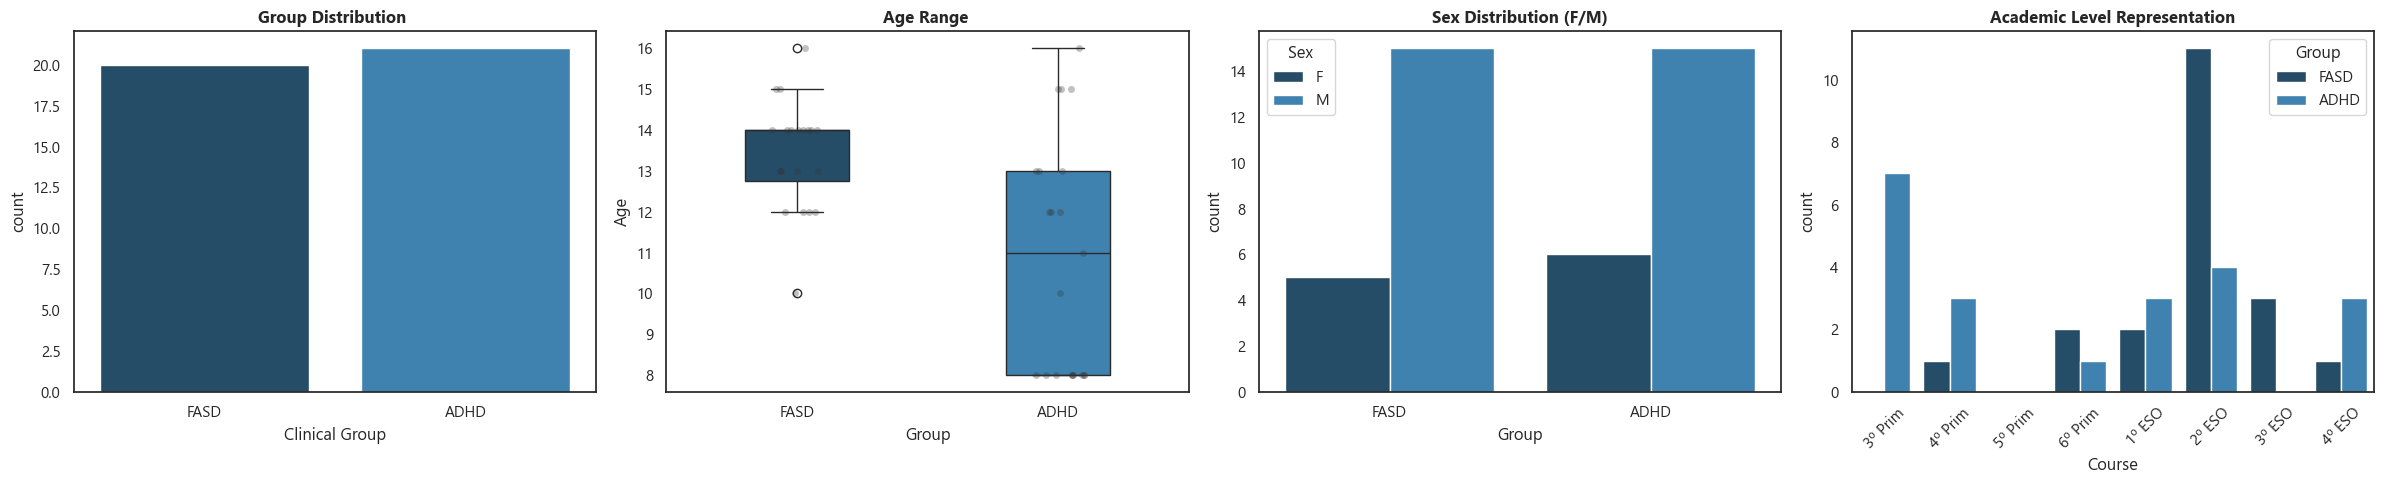

In [30]:
# ---- CELL 8: Run the initial demographic exploration (pre-QC sample) ----
df_demo = load_and_describe_demographics(
    file_path=PATH_DEMOGRAPHICS,
    table_title="Descriptive Sociodemographic Statistics — Initial Sample",
)
demographic_figures(df_demo, title_suffix="", stripplot_alpha=0.3)

## 1. EEG signal preprocessing

Only the eyes-closed resting-state condition is processed and analyzed in
this study. The pipeline proceeds as follows for every subject:
1. Load and standardize the raw BrainVision recording.
2. Crop the eyes-closed segment using its start/end triggers.
3. Apply notch + band-pass filtering.
4. Flag spatially inconsistent channels (RANSAC), deferring interpolation.
5. Remove ocular/muscular artifacts via ICA + ICLabel (with an EOG fallback).
6. Interpolate any flagged channels.
7. Segment into 2-second epochs and repair/reject noisy epochs (AutoReject).
8. Save the cleaned epochs and a per-subject preprocessing report.

In [6]:
# Pipeline parameters and trigger codes
params = {
    "low_freq": 0.5,              # High-pass filter (Hz)
    "high_freq": 50.0,            # Low-pass filter (Hz)
    "ica_l_freq": 1.0,            # High-pass filter applied only for ICA convergence
    "epoch_dur": 2.0,             # Duration of each segment (s)
    "ica_prob_threshold": 0.90,   # ICLabel confidence threshold
    "ransac_min_corr": 0.75,      # Minimum spatial correlation for RANSAC
    "mag_thresh": 300e-6,         # Peak-to-peak amplitude safety threshold (V)
}

EC_TRIGGERS = {'start': 'Stimulus/S 96', 'end': 'Stimulus/S 97'}

In [13]:
# Raw data loading and standardization
def load_and_setup_data(file_path):
    """
    Imports BrainVision raw data and performs initial standardization:
    standardized channel renaming, EOG channel mapping, and 10-20 montage
    alignment.
    """
    raw = mne.io.read_raw_brainvision(file_path, preload=True, verbose=False)

    channel_mapping = {'FZ': 'Fz', 'CZ': 'Cz', 'PZ': 'Pz', 'OZ': 'Oz'}
    raw.rename_channels({k: v for k, v in channel_mapping.items() if k in raw.ch_names})

    eog_map = {ch: 'eog' for ch in ['VEOU', 'HEOR'] if ch in raw.ch_names}
    if eog_map:
        raw.set_channel_types(eog_map)

    raw.set_montage('standard_1020', match_case=False, on_missing='warn')
    return raw

# Filtering 
def apply_initial_filtering(raw, params):
    """
    Applies frequency-domain filters to mitigate non-neural artifacts:
    a notch filter for power-line interference, and a zero-phase FIR
    band-pass filter for biological drift and high-frequency noise.
    """
    raw.notch_filter(freqs=50, fir_design='firwin', verbose=False)
    raw.filter(
        l_freq=params["low_freq"], h_freq=params["high_freq"],
        method='fir', phase='zero-double', verbose=False,
    )
    return raw

# Bad channel detection (RANSAC) 
def identify_bad_channels_ransac(raw, params):
    """
    Identifies spatially inconsistent sensors using RANSAC.
    Follows a 'deferred interpolation' strategy: sensors are flagged as
    'bads' but not repaired until ocular artifacts have been removed via ICA,
    so that bad sensors do not distort the ICA decomposition.
    """
    temp_epochs = mne.make_fixed_length_epochs(raw, duration=3.0, preload=True, verbose=False)

    ransac = Ransac(
        verbose=False, picks='eeg', n_jobs=1, random_state=42,
        min_corr=params["ransac_min_corr"],
    )
    ransac.fit(temp_epochs)

    raw.info['bads'] = ransac.bad_chs_
    return raw, raw.info['bads'].copy()

# ICA decomposition and artifact labeling 
def run_ica_decomposition(raw, params):
    """
    Executes Independent Component Analysis (ICA) with automated artifact
    detection. Integrates ICLabel for high-confidence classification of
    eye-blink and muscle components, with a conditional fallback that uses
    physical EOG channels if no blink component is confidently identified.
    """
    raw_for_ica = raw.copy().filter(l_freq=params["ica_l_freq"], h_freq=None, verbose=False)
    raw_for_ica.set_eeg_reference('average', projection=False, verbose=False)

    n_components = mne.compute_rank(raw_for_ica, rank='info')['eeg'] - 1
    ica = mne.preprocessing.ICA(
        n_components=n_components, method='infomax',
        fit_params=dict(extended=True), random_state=42,
    )
    ica.fit(raw_for_ica, picks="eeg", verbose=False)

    ic_labels = label_components(raw_for_ica, ica, method='iclabel')
    labels = ic_labels['labels']
    probas = [p.max() for p in ic_labels['y_pred_proba']]

    ica.exclude = [
        i for i, (label, p) in enumerate(zip(labels, probas))
        if label in ["eye blink", "muscle artifact"] and p >= params["ica_prob_threshold"]
    ]
    final_ic_details = [f"{labels[i]} ({probas[i]*100:.1f}%)" for i in ica.exclude]

    # Conditional EOG fallback: if no component was confidently labeled as a
    # blink, identify blink components via correlation with EOG channels.
    has_blink = any(labels[i] == "eye blink" for i in ica.exclude)
    if not has_blink:
        eog_chans = [ch for ch in ['VEOU', 'HEOR'] if ch in raw.ch_names]
        if eog_chans:
            eog_inds, _ = ica.find_bads_eog(raw_for_ica, ch_name=eog_chans, threshold=3.0, verbose=False)
            for idx in eog_inds:
                if idx not in ica.exclude:
                    ica.exclude.append(idx)
                    final_ic_details.append("eye blink (eog)")

    ic_string = ", ".join(final_ic_details) if final_ic_details else "None"
    return ica.apply(raw.copy(), verbose=False), ica, ic_string

# Epoching and AutoReject repair
def apply_autoreject_repair(raw_clean, params, n_ransac_bads=0):
    """
    Performs epoch segmentation and sensor-level repair using AutoReject.
    Also computes the Total Interpolation Density: the proportion of
    reconstructed data (global RANSAC interpolation + local AutoReject
    interpolation) relative to the total data volume. This metric is used
    downstream as a secondary quality-control criterion (Section 2).
    """
    events = mne.make_fixed_length_events(raw_clean, duration=params["epoch_dur"])
    n_theoretical = len(events)
    n_channels = len(raw_clean.ch_names)

    epochs = mne.Epochs(
        raw_clean, events, tmin=0, tmax=params["epoch_dur"] - (1 / raw_clean.info['sfreq']),
        baseline=None, detrend=1, preload=True, verbose=False,
    )

    ar = AutoReject(n_interpolate=[1, 2, 4], random_state=42, verbose=False)
    epochs_clean, reject_log = ar.fit_transform(epochs, return_log=True)
    ar_rejected = sum(reject_log.bad_epochs)

    epochs_clean.drop_bad(reject=dict(eeg=params["mag_thresh"]), verbose=False)
    final_epochs_count = len(epochs_clean)
    mag_dropped = n_theoretical - ar_rejected - final_epochs_count

    local_interpolations = np.sum(reject_log.labels == 1)
    global_interpolations = n_ransac_bads * len(epochs)
    total_interpolations = local_interpolations + global_interpolations
    total_data_units = len(epochs) * n_channels

    epochs_clean.set_eeg_reference('average', projection=False, verbose=False)

    stats_dict = {
        "theoretical": n_theoretical,
        "total_rejected": mag_dropped + ar_rejected,
        "epochs_repaired": np.any(reject_log.labels == 1, axis=1).sum(),
        "interp_density": (total_interpolations / total_data_units) * 100 if total_data_units > 0 else 0,
        "final": final_epochs_count,
    }
    return epochs_clean, stats_dict

# Manual inspection helper 
def visualize_eeg(file_path, title="EEG Inspection"):
    file_path = Path(file_path)
    suffix = file_path.suffix.lower()

    %matplotlib qt
    if suffix == '.vhdr':
        data = load_and_setup_data(str(file_path))
    elif suffix == '.fif':
        data = mne.read_epochs(file_path, preload=True, verbose=False)
    else:
        print("Format not supported. Use .vhdr for raw files or .fif for processed epochs.")
        return
    data.plot(block=True, title=title, scalings=dict(eeg=40e-6))
    %matplotlib inline

# Batch preprocessing pipeline (eyes-closed only)
def preproc_pipeline(path_raw_base, path_preproc_base, groups, params, ec_triggers):
    """
    Executes the full preprocessing pipeline across all subjects in both
    clinical groups, for the eyes-closed condition only.
    """
    all_subjects_stats = []

    for group in groups:
        path_group_raw = path_raw_base / group
        path_group_preproc = path_preproc_base / group
        path_group_preproc.mkdir(parents=True, exist_ok=True)

        vhdr_files = sorted(path_group_raw.glob("*.vhdr"))

        for file_path in vhdr_files:
            subject_id = file_path.stem

            try:
                print(f"Status: Processing {subject_id} | Condition: EC")

                raw = apply_initial_filtering(load_and_setup_data(str(file_path)), params)
                events, event_id = mne.events_from_annotations(raw, verbose=False)
                id_map = {k.strip(): v for k, v in event_id.items()}

                s_lab, e_lab = ec_triggers['start'].strip(), ec_triggers['end'].strip()
                if s_lab not in id_map or e_lab not in id_map:
                    print(f"Warning: Eyes-closed triggers missing for {subject_id}")
                    continue

                t_start = events[events[:, 2] == id_map[s_lab]][0, 0] / raw.info['sfreq']
                t_end = events[events[:, 2] == id_map[e_lab]][0, 0] / raw.info['sfreq']
                duration = t_end - t_start

                raw_seg = raw.copy().crop(tmin=t_start, tmax=t_end)
                raw_seg, ransac_bads = identify_bad_channels_ransac(raw_seg, params)
                raw_clean, ica, ic_string = run_ica_decomposition(raw_seg, params)

                if raw_clean.info['bads']:
                    raw_clean.interpolate_bads(reset_bads=True)

                epochs, ep_stats = apply_autoreject_repair(raw_clean, params, n_ransac_bads=len(ransac_bads))

                out_name = f"{subject_id}_ce-epo.fif"
                epochs.save(path_group_preproc / out_name, overwrite=True, verbose=False)

                all_subjects_stats.append({
                    "Subject": subject_id,
                    "Group": group,
                    "Phase": "CE",
                    "Phase Duration": f"{duration:.2f}s",
                    "Global Bad Channels": ", ".join(ransac_bads) if ransac_bads else "None",
                    "ICA Comp. Removed": len(ica.exclude),
                    "ICLabel": ic_string,
                    "Rejected Epochs": f"{ep_stats['total_rejected']}/{ep_stats['theoretical']}",
                    "Repaired Epochs": f"{ep_stats['epochs_repaired']}/{ep_stats['theoretical']}",
                    "Interpol. Density": f"{round(ep_stats['interp_density'], 2)}%",
                    "Final Epoch Count": f"{ep_stats['final']}/{ep_stats['theoretical']}",
                    "Data Retained %": f"{round((ep_stats['final'] / ep_stats['theoretical']) * 100, 1)}%",
                })

                gc.collect()

            except Exception as e:
                print(f"Critical Error: {subject_id} failed due to: {e}")

        group_df = pd.DataFrame([s for s in all_subjects_stats if s["Group"] == group])
        report_path = path_group_preproc / f"{group}_Preprocessing_Report.xlsx"
        group_df.to_excel(report_path, index=False)
        print(f"Group report saved: {report_path.name}")

    final_report_df = pd.DataFrame(all_subjects_stats)
    print("\nBatch processing complete. Returning consolidated report.")
    return final_report_df

# Display a group preprocessing report 
def display_report_from_excel(excel_path, table_title):
    df = pd.read_excel(excel_path)
    show_table(df, table_title)
    return df

In [8]:
# Run the preprocessing pipeline
all_stats_df = preproc_pipeline(
    path_raw_base=PATH_RAW,
    path_preproc_base=PATH_PREPROC,
    groups=CLINICAL_GROUPS,
    params=params,
    ec_triggers=EC_TRIGGERS,
)

Status: Processing sub-01_fasd | Condition: EC
Status: Processing sub-02_fasd | Condition: EC
Status: Processing sub-03_fasd | Condition: EC
Status: Processing sub-04_fasd | Condition: EC
Status: Processing sub-05_fasd | Condition: EC
Status: Processing sub-06_fasd | Condition: EC
Status: Processing sub-07_fasd | Condition: EC
Status: Processing sub-08_fasd | Condition: EC
Status: Processing sub-09_fasd | Condition: EC
Status: Processing sub-10_fasd | Condition: EC
Status: Processing sub-11_fasd | Condition: EC
Status: Processing sub-12_fasd | Condition: EC
Status: Processing sub-13_fasd | Condition: EC
Status: Processing sub-14_fasd | Condition: EC
Status: Processing sub-15_fasd | Condition: EC
Status: Processing sub-16_fasd | Condition: EC
Status: Processing sub-17_fasd | Condition: EC
Status: Processing sub-18_fasd | Condition: EC
Status: Processing sub-19_fasd | Condition: EC
Status: Processing sub-20_fasd | Condition: EC
Group report saved: FASD_Preprocessing_Report.xlsx
Status: P

In [9]:
# Display a group preprocessing report 
_ = display_report_from_excel(
    PATH_PREPROC / "ADHD" / "ADHD_Preprocessing_Report.xlsx",
    table_title="ADHD Preprocessing Report",
)

Subject,Group,Phase,Phase Duration,Global Bad Channels,ICA Comp. Removed,ICLabel,Rejected Epochs,Repaired Epochs,Interpol. Density,Final Epoch Count,Data Retained %
sub-01_adhd,ADHD,CE,157.07s,NaN,2,"eye blink (98.6%), eye blink (99.4%)",12/78,25/78,9.02%,66/78,84.6%
sub-02_adhd,ADHD,CE,138.08s,NaN,3,"eye blink (98.2%), eye blink (99.8%), muscle artifact (95.4%)",6/69,23/69,10.72%,63/69,91.3%
sub-03_adhd,ADHD,CE,149.66s,NaN,2,"eye blink (99.7%), eye blink (99.2%)",10/74,26/74,12.3%,64/74,86.5%
sub-04_adhd,ADHD,CE,157.52s,NaN,6,"eye blink (99.7%), eye blink (100.0%), muscle artifact (99.4%), muscle artifact (99.7%), eye blink (92.4%), eye blink (92.3%)",11/78,17/78,7.35%,67/78,85.9%
sub-05_adhd,ADHD,CE,156.04s,NaN,2,"eye blink (99.1%), eye blink (99.9%)",42/78,67/78,35.04%,36/78,46.2%
sub-06_adhd,ADHD,CE,151.29s,NaN,2,"eye blink (eog), eye blink (eog)",5/75,32/75,9.82%,70/75,93.3%
sub-07_adhd,ADHD,CE,138.41s,NaN,4,"eye blink (93.9%), eye blink (99.7%), muscle artifact (98.3%), muscle artifact (95.3%)",14/69,47/69,21.45%,55/69,79.7%
sub-08_adhd,ADHD,CE,119.22s,NaN,2,"eye blink (96.6%), eye blink (94.1%)",20/59,33/59,24.97%,39/59,66.1%
sub-09_adhd,ADHD,CE,164.19s,NaN,2,"eye blink (98.5%), eye blink (99.8%)",34/82,40/82,14.84%,48/82,58.5%
sub-10_adhd,ADHD,CE,167.50s,NaN,2,"eye blink (99.0%), eye blink (99.4%)",28/83,34/83,19.64%,55/83,66.3%


### Optional: manual signal inspection (run locally, not on GitHub)

The two cells below open an interactive Qt window to visually compare a
subject's raw and cleaned signal.

In [14]:
visualize_eeg(PATH_RAW / "ADHD" / "sub-01_adhd.vhdr", title="Raw — sub-01 (ADHD)")

In [15]:
visualize_eeg(PATH_PREPROC / "ADHD" / "sub-01_adhd_ce-epo.fif", title="Cleaned — sub-01 (ADHD)")

## 2. Data cleaning

This section performs three tasks:
1. Quality-control screening of the preprocessed epochs (retention rate,
   interpolation density, total clean duration) to determine the final
   analyzable cohort.
2. Demographic and statistical characterization of that final cohort.
3. Fragmentation of subject-level epochs into individual 2-second trials,
   followed by class balancing via random downsampling, and synchronization
   of the balanced trial set with the demographic and neuropsychological
   databases.

In [31]:
# Additional derived paths (cleaned / balanced data)
# They are declared here since this is the point at which the corresponding files are first created.
PATH_DEMOGRAPHICS_CLEAN     = BASE_DIR / "demographics_cleaned.xlsx"
PATH_NP_SCORES_CLEAN        = BASE_DIR / "np_scores_cleaned.xlsx"
PATH_DEMOGRAPHICS_BALANCED  = BASE_DIR / "demographics_balanced.xlsx"
PATH_NP_SCORES_BALANCED     = BASE_DIR / "np_scores_balanced.xlsx"

qc_params = {
    "min_retention": 50.0,   # Minimum % of epochs retained after rejection
    "max_density": 30.0,     # Maximum % of signal that can be interpolated
    "min_duration": 40.0,    # Minimum required clean signal duration (s)
    "epoch_length": 2.0,     # Duration of each individual segment (s)
}

In [32]:
# Quality-control helper functions
def parse_ratio_to_pct(ratio_str):
    """Converts a 'x/y' string (e.g. rejected/total epochs) into a percentage."""
    try:
        num, den = ratio_str.split('/')
        return (int(num) / int(den)) * 100
    except (ValueError, AttributeError):
        return 0

def get_quality_report_table(df):
    """Aggregates retention, interpolation density and ICA counts by group/phase."""
    summary = df.groupby(['Group', 'Phase']).agg({
        'Retention_Num': ['mean', 'std'],
        'Density_Num': ['mean', 'std'],
        'ICA_Count': ['mean', 'std'],
    }).round(2)

    rows = []
    for (group, phase), data in summary.iterrows():
        rows.append({
            'Group': group,
            'Condition': 'Closed Eyes' if phase == 'CE' else phase,
            'Data Retention (%)': f"{data[('Retention_Num', 'mean')]} ± {data[('Retention_Num', 'std')]}",
            'Interpolation Density (%)': f"{data[('Density_Num', 'mean')]} ± {data[('Density_Num', 'std')]}",
            'ICA Components Removed': f"{data[('ICA_Count', 'mean')]} ± {data[('ICA_Count', 'std')]}",
        })
    return pd.DataFrame(rows).set_index(['Group', 'Condition'])

def get_exclusion_reason(row, qc_params):
    """Builds a human-readable string of which QC criteria a subject failed."""
    reasons = []
    if row['Retention_Num'] < qc_params["min_retention"]:
        reasons.append("Low Retention")
    if row['Density_Num'] > qc_params["max_density"]:
        reasons.append("High Interpolation")
    if row['Total_Clean_Seconds'] < qc_params["min_duration"]:
        reasons.append("Insufficient Duration")
    return " + ".join(reasons)

def stat_summary(df, group_order=('FASD', 'ADHD'), table_title="Demographics Statistical Summary"):
    """
    Reproduces Table 2.1 of the thesis:
      - Age normality per group (Shapiro-Wilk)
      - Age group comparison (Mann-Whitney U, rank-biserial r)
      - Sex distribution by group (Pearson's Chi-Square, Cramér's V)
      - Education level by group (Pearson's Chi-Square, Cramér's V)
    """
    grp1_name, grp2_name = group_order
    results_data = []

    # --- Age normality (Shapiro-Wilk), per group ---
    for grp in group_order:
        age_data = df.loc[df['Group'] == grp, 'Age'].dropna()
        stat, p_val = shapiro(age_data)
        results_data.append({
            "Metric": f"Age Normality ({grp})",
            "Test": "Shapiro-Wilk",
            "Statistic": f"W = {stat:.3f}",
            "p-value": f"{p_val:.3f}",
        })

    # --- Age comparison (Mann-Whitney U, rank-biserial r) ---
    grp1_age = df.loc[df['Group'] == grp1_name, 'Age'].dropna()
    grp2_age = df.loc[df['Group'] == grp2_name, 'Age'].dropna()

    u_stat, p_u = mannwhitneyu(grp1_age, grp2_age, alternative='two-sided')
    n1, n2 = len(grp1_age), len(grp2_age)
    rank_biserial_r = u_stat / (n1 * n2)  # equivalent to the common-language effect size

    results_data.append({
        "Metric": f"Age Comparison ({grp1_name} vs {grp2_name})",
        "Test": "Mann-Whitney U",
        "Statistic": f"U = {u_stat:.1f}, r = {rank_biserial_r:.3f}",
        "p-value": f"{p_u:.3f}",
    })

    def _chi_square_block(column, metric_label):
        """Runs Pearson's Chi-Square + Cramér's V for a categorical variable."""
        contingency_table = pd.crosstab(df['Group'], df[column])
        if contingency_table.size == 0:
            return None

        chi2, p_chi, dof, _ = chi2_contingency(contingency_table)
        n_total = contingency_table.values.sum()
        k = min(contingency_table.shape) - 1
        cramers_v = np.sqrt(chi2 / (n_total * k)) if k > 0 else np.nan

        return {
            "Metric": metric_label,
            "Test": "Chi-Square",
            "Statistic": f"\u03c7\u00b2({dof}) = {chi2:.2f}, V = {cramers_v:.3f}",
            "p-value": f"{p_chi:.3f}",
        }

    sex_result = _chi_square_block('Sex', "Sex Distribution by Group")
    if sex_result:
        results_data.append(sex_result)

    edu_result = _chi_square_block('Education', "Education Level by Group")
    if edu_result:
        results_data.append(edu_result)

    results_df = pd.DataFrame(results_data)
    show_table(results_df, table_title)
    return results_df

In [33]:
# Load and merge per-group preprocessing reports 
df_fasd_report = pd.read_excel(PATH_PREPROC / "FASD" / "FASD_Preprocessing_Report.xlsx")
df_adhd_report = pd.read_excel(PATH_PREPROC / "ADHD" / "ADHD_Preprocessing_Report.xlsx")
df_master = pd.concat([df_fasd_report, df_adhd_report], ignore_index=True)

df_master['Retention_Num'] = df_master['Data Retained %'].str.rstrip('%').astype(float)
df_master['Density_Num']   = df_master['Interpol. Density'].str.rstrip('%').astype(float)
df_master['Rejected_Pct']  = df_master['Rejected Epochs'].apply(parse_ratio_to_pct)
df_master['ICA_Count']     = df_master['ICA Comp. Removed'].astype(int)
df_master['Group_Phase']   = df_master['Group'] + " " + df_master['Phase']

quality_hierarchical = get_quality_report_table(df_master)
show_table(quality_hierarchical.reset_index(), "Data Integrity and Preprocessing Metrics")

Group,Condition,Data Retention (%),Interpolation Density (%),ICA Components Removed
ADHD,Closed Eyes,78.5 ± 14.34,14.31 ± 8.19,2.48 ± 0.98
FASD,Closed Eyes,87.88 ± 10.71,10.46 ± 6.84,2.6 ± 0.68


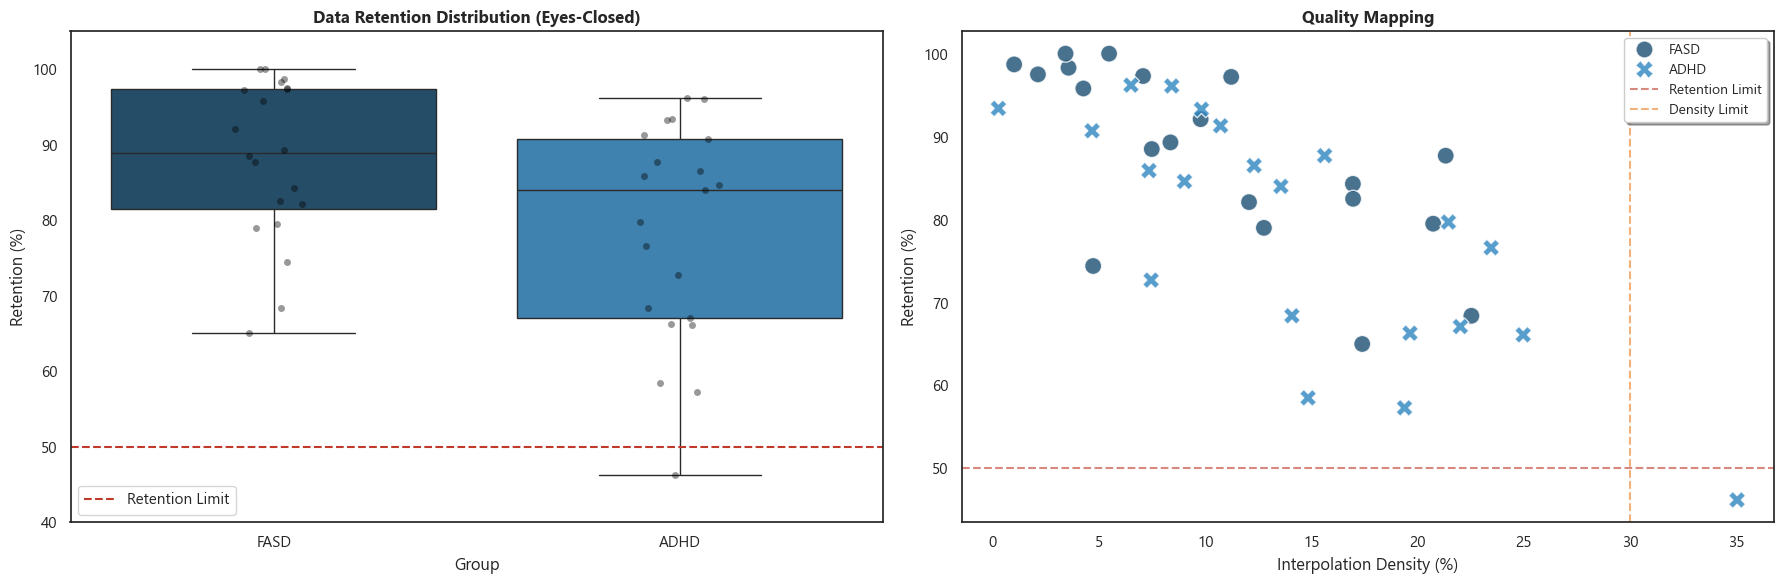

In [34]:
# Quality-control visualization
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Panel A: data retention distribution by group
sns.boxplot(ax=axes[0], x='Group', y='Retention_Num', hue='Group',
            data=df_master, palette=table_palette, showfliers=False, legend=False)
sns.stripplot(ax=axes[0], x='Group', y='Retention_Num',
              data=df_master, color='black', alpha=0.4, jitter=True)
line_ret = axes[0].axhline(y=qc_params["min_retention"], color='#C0392B', linestyle='--',
                            linewidth=1.5, label='Retention Limit')
axes[0].set_title('Data Retention Distribution (Eyes-Closed)', fontweight='bold')
axes[0].set_ylabel('Retention (%)')
axes[0].set_ylim(40, 105)
axes[0].legend(handles=[line_ret], loc='lower left', frameon=True)

# Panel B: joint mapping of retention vs. interpolation density, by group
sns.scatterplot(ax=axes[1], x='Density_Num', y='Retention_Num',
                 hue='Group', style='Group', palette=table_palette,
                 s=150, data=df_master, alpha=0.8)
l_hline = axes[1].axhline(y=qc_params["min_retention"], color='#C0392B', linestyle='--', alpha=0.6)
l_vline = axes[1].axvline(x=qc_params["max_density"], color='#E67E22', linestyle='--', alpha=0.6)
axes[1].set_title('Quality Mapping', fontweight='bold')
axes[1].set_xlabel('Interpolation Density (%)')
axes[1].set_ylabel('Retention (%)')
h_b, l_b = axes[1].get_legend_handles_labels()
axes[1].legend(handles=h_b + [l_hline, l_vline], labels=l_b + ['Retention Limit', 'Density Limit'],
                loc='upper right', frameon=True, shadow=True, fontsize='small')

plt.tight_layout()
plt.show()
plt.close()

In [35]:
# Apply exclusion criteria
df_master['Final_Count'] = df_master['Final Epoch Count'].str.split('/').str[0].astype(int)
df_master['Total_Clean_Seconds'] = df_master['Final_Count'] * qc_params["epoch_length"]

exclusion_criteria = (
    (df_master['Retention_Num'] < qc_params["min_retention"]) |
    (df_master['Density_Num'] > qc_params["max_density"]) |
    (df_master['Total_Clean_Seconds'] < qc_params["min_duration"])
)

df_excluded = df_master[exclusion_criteria].copy()
if not df_excluded.empty:
    df_excluded['Exclusion_Reason'] = df_excluded.apply(get_exclusion_reason, qc_params=qc_params, axis=1)

df_final_clean = df_master.drop(df_excluded.index).reset_index(drop=True)

if not df_excluded.empty:
    report_cols = {
        'Subject': 'Subject', 'Group': 'Group', 'Phase': 'Phase',
        'Retention_Num': 'Retention (%)', 'Density_Num': 'Interpolation (%)',
        'Total_Clean_Seconds': 'Duration (s)', 'Exclusion_Reason': 'Reason for Exclusion',
    }
    show_table(df_excluded[list(report_cols.keys())].rename(columns=report_cols),
               "Quality Control Exclusion Report")
else:
    display(HTML("<p style='color:#1B4F72; font-family:Segoe UI;'><b>Note:</b> "
                  "All samples met the quality criteria. No subjects were excluded.</p>"))

print(f"Total segments processed: {len(df_master)}")
print(f"Segments excluded:        {len(df_excluded)}")
print(f"Valid segments retained:  {len(df_final_clean)}")

Subject,Group,Phase,Retention (%),Interpolation (%),Duration (s),Reason for Exclusion
sub-05_adhd,ADHD,CE,46.2,35.04,72.0,Low Retention + High Interpolation


Total segments processed: 41
Segments excluded:        1
Valid segments retained:  40


In [36]:
# Sample-size attrition summary
counts_original = df_master.groupby(['Group', 'Phase']).size().reset_index(name='Original')
counts_cleaned = df_final_clean.groupby(['Group', 'Phase']).size().reset_index(name='Cleaned')
attrition_df = pd.merge(counts_original, counts_cleaned, on=['Group', 'Phase'], how='left').fillna(0)
attrition_df['Excluded'] = (attrition_df['Original'] - attrition_df['Cleaned']).astype(int)
attrition_df['Condition'] = attrition_df['Phase'].map({'CE': 'Closed Eyes'})

sample_report = attrition_df.set_index(['Group', 'Condition'])[['Original', 'Cleaned', 'Excluded']]
show_table(sample_report.reset_index(), "Sample Size Attrition by Condition")

unique_summary = []
for group in CLINICAL_GROUPS:
    orig_n = df_master[df_master['Group'] == group]['Subject'].nunique()
    clean_n = df_final_clean[df_final_clean['Group'] == group]['Subject'].nunique()
    unique_summary.append({
        'Clinical Group': group,
        'Original Subjects (N)': orig_n,
        'Cleaned Subjects (n)': clean_n,
        'Total Exclusions': orig_n - clean_n,
        'Retention Rate': f"{(clean_n / orig_n) * 100:.1f}%",
    })

show_table(pd.DataFrame(unique_summary), "Final Subject Retention Summary")
gc.collect()

Group,Condition,Original,Cleaned,Excluded
ADHD,Closed Eyes,21,20,1
FASD,Closed Eyes,20,20,0


Clinical Group,Original Subjects (N),Cleaned Subjects (n),Total Exclusions,Retention Rate
FASD,20,20,0,100.0%
ADHD,21,20,1,95.2%


10969

### Multimodal Dataset Synchronization

Subjects that passed quality control on the eyes-closed condition are used
to filter the demographic and neuropsychological databases, so that all
three sources (EEG, demographics, NP scores) refer to the exact same final
cohort.

In [37]:
# Synchronize demographics and NP scores with the valid cohort 
df_demo_raw = pd.read_excel(PATH_DEMOGRAPHICS).rename(columns={'ID': 'Subject'})
df_np_raw = pd.read_excel(PATH_NP_SCORES).rename(columns={'ID': 'Subject'})

df_final_ce = df_final_clean[df_final_clean['Phase'] == 'CE'].copy()
valid_subjects = df_final_ce['Subject'].unique()

df_demo_cleaned = df_demo_raw[df_demo_raw['Subject'].isin(valid_subjects)].copy()
df_np_cleaned = df_np_raw[df_np_raw['Subject'].isin(valid_subjects)].copy()

df_demo_cleaned.to_excel(PATH_DEMOGRAPHICS_CLEAN, index=False)
df_np_cleaned.to_excel(PATH_NP_SCORES_CLEAN, index=False)

sync_summary = pd.DataFrame([{
    'EEG Records (CE)': len(valid_subjects),
    'Demographics Records': len(df_demo_cleaned),
    'NP Scores Records': len(df_np_cleaned),
    'Synchronization Status': 'Complete (1:1:1 Match)',
}])
show_table(sync_summary, "Database Synchronization Summary")

EEG Records (CE),Demographics Records,NP Scores Records,Synchronization Status
40,40,40,Complete (1:1:1 Match)


Variable,FASD,ADHD
Count (n),20,20
Age (years),13.40 ± 1.35 [10.0 - 16.0],11.05 ± 2.91 [8.0 - 16.0]
Sex (F:M),5:15,6:14


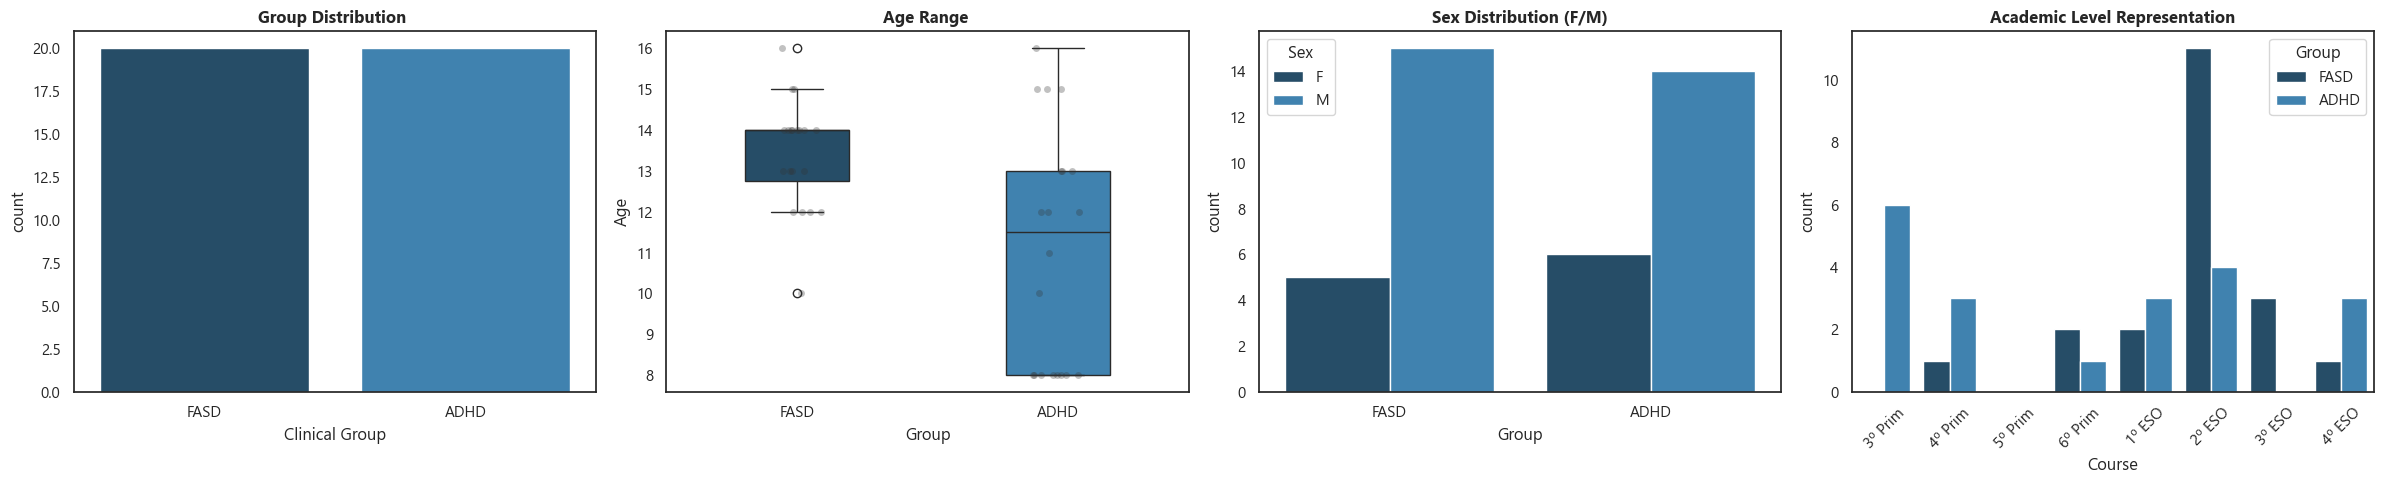

In [38]:
# Descriptive statistics for the final clean cohort
df_demo_cleaned_loaded = load_and_describe_demographics(
    file_path=PATH_DEMOGRAPHICS_CLEAN,
    table_title="Descriptive Sociodemographic Statistics — Final Cohort (N=40)",
)
demographic_figures(df_demo_cleaned_loaded, title_suffix="", stripplot_alpha=0.3)

In [39]:
# Run the statistical summary
df_demo_for_stats = pd.read_excel(PATH_DEMOGRAPHICS_CLEAN)
stats_df = stat_summary(df_demo_for_stats, table_title="Demographics Statistical Tests (Table 2.1)")

Metric,Test,Statistic,p-value
Age Normality (FASD),Shapiro-Wilk,W = nan,nan
Age Normality (ADHD),Shapiro-Wilk,W = nan,nan
Age Comparison (FASD vs ADHD),Mann-Whitney U,"U = nan, r = nan",nan
Sex Distribution by Group,Chi-Square,"χ²(1) = 0.00, V = 0.000",1.000
Education Level by Group,Chi-Square,"χ²(6) = 14.80, V = 0.608",0.022


### Epoch-based segmentation

Each subject's cleaned, continuous set of epochs is split into individual
2-second trials saved as separate files. This is the unit of analysis used
for feature extraction and classification (Section 2.4–2.5 of the thesis).
Only subjects that passed quality control (`valid_subjects`, Section 2) are
fragmented.

In [40]:
# Fragment cleaned epochs into individual trial files
def fragment_epochs_to_disk(valid_subjects_list, source_root, target_root, groups):
    """
    Splits each subject's continuous epoch file into individual trial files
    (one .fif per 2-second segment), saved under target_root/<group>/.
    Only subjects present in valid_subjects_list are processed.
    """
    valid_ids = {str(s).strip().lower() for s in valid_subjects_list}
    total_saved = 0

    for group in groups:
        group_input_path = source_root / group
        group_output_path = target_root / group
        group_output_path.mkdir(parents=True, exist_ok=True)

        epoch_files = [f for f in os.listdir(group_input_path) if f.endswith('_ce-epo.fif')]

        for file_name in tqdm(epoch_files, desc=f"Fragmenting {group}"):
            subject_id = file_name.replace('_ce-epo.fif', '').strip().lower()
            if subject_id not in valid_ids:
                continue

            epochs_data = mne.read_epochs(group_input_path / file_name, preload=True, verbose=False)

            for i in range(len(epochs_data)):
                trial_index = i + 1
                new_filename = f"{subject_id}_ce-epo_e{trial_index}.fif"
                epochs_data[i].save(group_output_path / new_filename, overwrite=True, verbose=False)
                total_saved += 1

    print(f"\nFragmentation complete. Total individual trials saved: {total_saved}")
    return total_saved

total_trials = fragment_epochs_to_disk(
    valid_subjects_list=valid_subjects,
    source_root=PATH_PREPROC,
    target_root=PATH_EPOCHS,
    groups=CLINICAL_GROUPS,
)

Fragmenting ADHD: 100%|████████████████████████████████████████████████████████████████| 21/21 [00:14<00:00,  1.44it/s]


Fragmentation complete. Total individual trials saved: 2530


### Trial-level demographic weighting

Since every subject contributes multiple 2-second trials, the demographic
distribution at the trial level is not the same as at the subject level
(subjects with more retained epochs are proportionally over-represented).
This step characterizes that trial-weighted distribution for transparency,
before any class balancing is applied.

Variable,FASD,ADHD
Count (n),1330,1200
Age (years),13.40 ± 1.36 [10.0 - 16.0],11.23 ± 2.87 [8.0 - 16.0]
Sex (F:M),325:1005,354:846


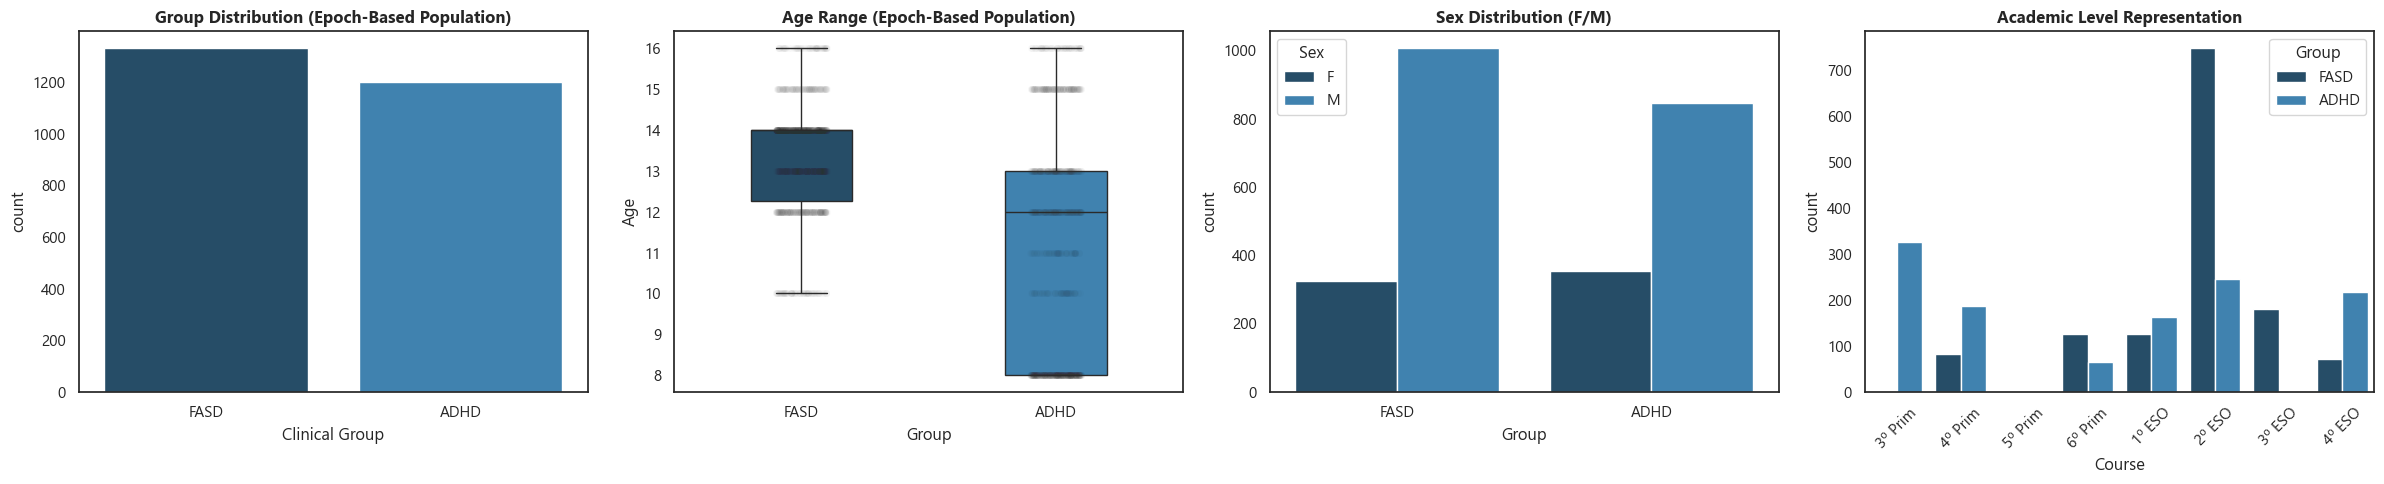

In [44]:
def index_epoch_files(epochs_root, groups):
    """Lists every individual trial file and extracts its lowercase subject ID."""
    records = []
    for group in groups:
        group_path = epochs_root / group
        if not group_path.exists():
            continue
        for f in os.listdir(group_path):
            if f.endswith('.fif'):
                subject_id = f.split('_ce-epo')[0].strip().lower()
                records.append({'Subject_ID_Lower': subject_id, 'Epoch_File': f, 'Group': group})
    return pd.DataFrame(records)


df_epochs_idx = index_epoch_files(PATH_EPOCHS, CLINICAL_GROUPS)

df_demo_base = pd.read_excel(PATH_DEMOGRAPHICS_CLEAN)
df_demo_base['Subject_ID_Lower'] = df_demo_base['Subject'].astype(str).str.strip().str.lower()
df_demo_base_no_group = df_demo_base.drop(columns=['Group'], errors='ignore')
df_epoch_raw = pd.merge(df_epochs_idx, df_demo_base_no_group, on='Subject_ID_Lower')

df_epoch_weighted = load_and_describe_demographics(
    df_input=df_epoch_raw,
    table_title=f"Descriptive Sociodemographic Statistics — Epoch-Based Population (N={len(df_epoch_raw)})",
)

demographic_figures(
    df=df_epoch_weighted,
    title_suffix="(Epoch-Based Population)",
    stripplot_alpha=0.02,
)

### Addressing class imbalance via random downsampling

Different recording durations led to an imbalance in total retained epochs
between groups. Random downsampling without replacement is applied to the
majority class to produce a balanced dataset (1:1 ratio), preventing
classifier bias toward the larger group (Methods, Section 2.3).

Variable,FASD,ADHD
Unique Subjects (N),20,20
Count (n),1200,1200
Age (years),13.41 ± 1.36 [10.0 - 16.0],11.23 ± 2.87 [8.0 - 16.0]
Sex (F:M),297:903,354:846


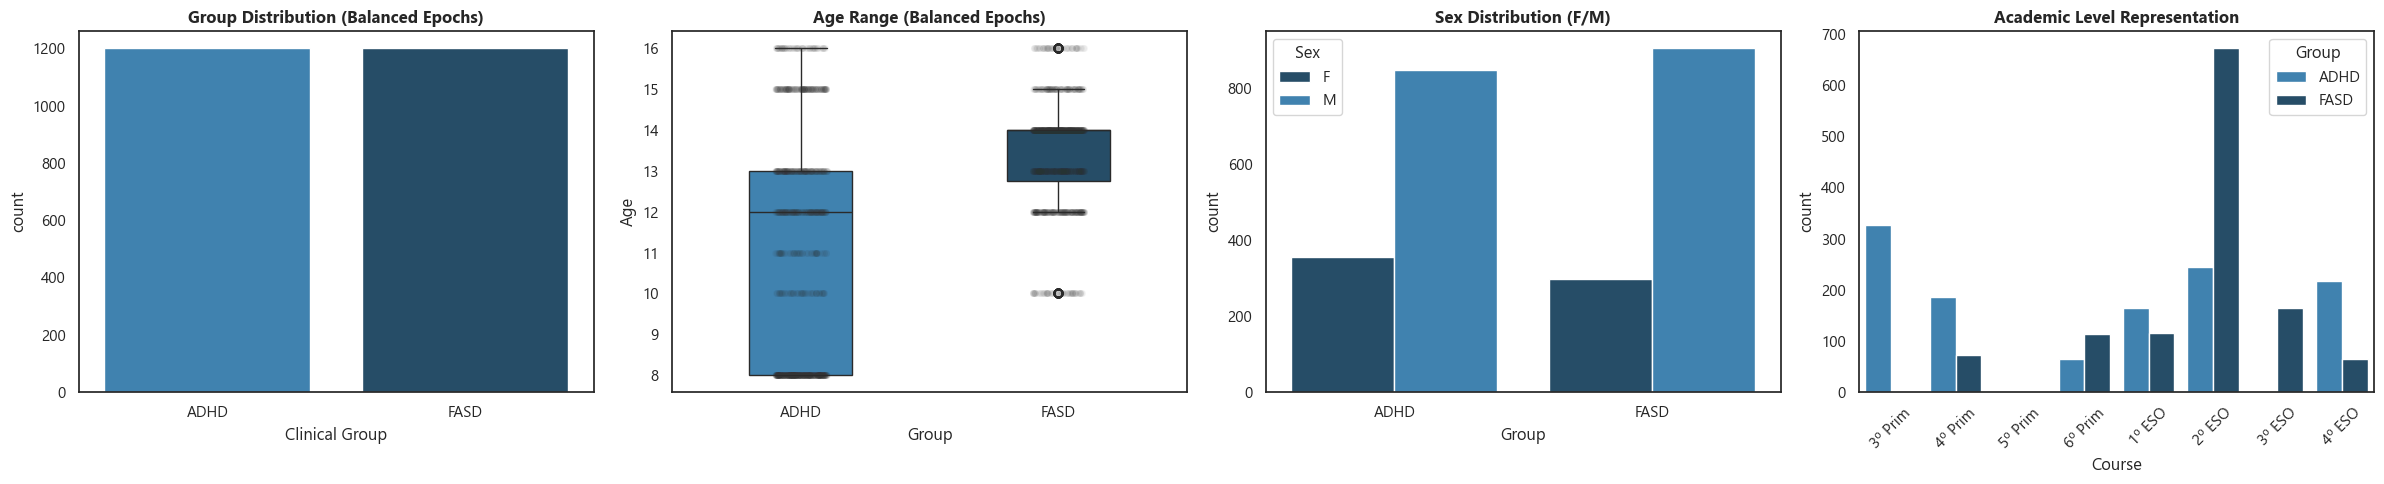

In [45]:
RANDOM_SEED = 42

group_counts = df_epoch_weighted['group_label'].value_counts()
minority_size = group_counts.min()

df_balanced = (
    df_epoch_weighted
    .groupby('group_label', group_keys=False)
    .apply(lambda x: x.sample(n=minority_size, random_state=RANDOM_SEED))
    .reset_index(drop=True)
)

subjects_retained = df_balanced.groupby('group_label')['Subject'].nunique().to_dict()

epoch_desc_table = demographic_table(df_balanced)
new_row = pd.DataFrame({
    'Variable': ['Unique Subjects (N)'],
    'FASD': [subjects_retained.get('FASD', 0)],
    'ADHD': [subjects_retained.get('ADHD', 0)],
})
epoch_desc_table = pd.concat([new_row, epoch_desc_table], ignore_index=True)

show_table(epoch_desc_table, f"Balanced Descriptive Sociodemographic Statistics (N={len(df_balanced)})")

demographic_figures(df=df_balanced, title_suffix="(Balanced Epochs)", stripplot_alpha=0.05)

### Physical synchronization of the balanced epoch set

The trial files selected by downsampling are copied into a dedicated
`balanced_epochs/` directory, mirroring the per-group structure used so far.
This keeps the original `epochs/` directory intact as the full unbalanced
pool, while `balanced_epochs/` holds exactly the 2,400 trials used in the
classification pipeline.

In [46]:
for _, row in tqdm(df_balanced.iterrows(), total=len(df_balanced), desc="Syncing Balanced Epochs"):
    group_label = row['group_label']
    filename = row['Epoch_File']

    source_file_path = PATH_EPOCHS / group_label / filename
    target_file_path = PATH_BALANCED / group_label / filename

    if source_file_path.exists():
        shutil.copy2(source_file_path, target_file_path)
    else:
        print(f"Warning: Source file not found at {source_file_path}")

for group in CLINICAL_GROUPS:
    file_count = len(list((PATH_BALANCED / group).glob("*.fif")))
    print(f"Group {group}: {file_count} validated 2-second epochs")

print(f"Total entries in Balanced_Epochs: {len(df_balanced)} observations")

Syncing Balanced Epochs: 100%|████████████████████████████████████████████████████| 2400/2400 [00:20<00:00, 115.21it/s]

Group FASD: 1200 validated 2-second epochs
Group ADHD: 1200 validated 2-second epochs
Total entries in Balanced_Epochs: 2400 observations


### Final multimodal synchronization

Each balanced trial is paired with its subject's demographic and
neuropsychological profile via a broadcast join: every 2-second trial of a
given subject receives that subject's (constant) clinical and demographic
values. This produces the trial-level multimodal dataset later used for
feature extraction and classification.

In [47]:
df_balanced_index = index_epoch_files(PATH_BALANCED, CLINICAL_GROUPS)

df_demo_source = pd.read_excel(PATH_DEMOGRAPHICS_CLEAN)
df_np_source = pd.read_excel(PATH_NP_SCORES_CLEAN)

df_demo_source['Subject_ID_Lower'] = df_demo_source['Subject'].astype(str).str.strip().str.lower()
df_np_source['Subject_ID_Lower'] = df_np_source['Subject'].astype(str).str.strip().str.lower()

df_demo_balanced = pd.merge(df_balanced_index, df_demo_source, on='Subject_ID_Lower', how='inner')
df_np_balanced = pd.merge(df_balanced_index, df_np_source, on='Subject_ID_Lower', how='inner')

df_demo_balanced.drop(columns=['Subject_ID_Lower']).to_excel(PATH_DEMOGRAPHICS_BALANCED, index=False)
df_np_balanced.drop(columns=['Subject_ID_Lower']).to_excel(PATH_NP_SCORES_BALANCED, index=False)

sync_summary = pd.DataFrame([{
    'Balanced Epochs (N)': len(df_balanced_index),
    'Demographics (N_trials)': len(df_demo_balanced),
    'NP Scores (N_trials)': len(df_np_balanced),
    'Status': 'Synchronized (1:1:1)',
}])
show_table(sync_summary, f"Trial-Based Database Synchronization Summary (N={len(df_balanced_index)})")

unique_subjects = df_demo_balanced['Subject'].nunique()
print(f"Unique subjects represented in the balanced trial set: {unique_subjects}")

Balanced Epochs (N),Demographics (N_trials),NP Scores (N_trials),Status
2400,2400,2400,Synchronized (1:1:1)


Unique subjects represented in the balanced trial set: 40


## 3. EEG feature extraction & classification engine

This section builds the EEG feature matrix and the core nested-LOSO
classification engine used for the univariate and bivariate
analyses. Multimodal fusion and NP-specific selection reuse
`execute_nested_loso_pipeline` directly and are introduced later with their
own functions.

Engine design:
- L1-regularized linear SVM, nested LOSO (outer: held-out subject; inner:
  LOSO on the remaining subjects to select C from `C_GRID`).
- Confound removal (age + sex) fit on training data only, then applied to
  the test fold.
- Epoch-level metrics: Accuracy and AUC only (discrimination).
- Subject-level metrics (majority voting): Accuracy, AUC, Sensitivity,
  Specificity, Precision, Balanced Accuracy, Net Benefit (clinical utility).
  Ties in majority voting default to the FASD class (Eq. 2.10).
- Haufe-transformed activation patterns and L1 stability (% of folds with a
  non-zero coefficient) computed per feature/channel.

### 3.1 EEG features matrix

In [51]:
# Path config addendum (EEG features) 
PATH_EEG_FEATURES = BASE_DIR / "eeg_features"
PATH_EEG_FEATURES.mkdir(parents=True, exist_ok=True)
(PATH_EEG_FEATURES / "ROC_SUBJECT").mkdir(parents=True, exist_ok=True)

In [54]:
# EEG feature definitions
FREQUENCY_BANDS = {
    'delta':  (1.5, 4.0),
    'theta':  (4.5, 7.0),
    'alpha':  (8.0, 13.0),
    'alpha1': (8.0, 10.0),
    'alpha2': (10.5, 13.0),
    'beta':   (14.0, 30.0),
    'beta1':  (14.0, 20.0),
    'beta2':  (20.5, 30.0),
}

EEG_FEATURE_NAMES = (
    ['Activity', 'Mobility', 'Complexity']
    + [band.capitalize() for band in FREQUENCY_BANDS]
    + ['TBR', 'SampEn', 'HFD']
)

In [72]:
# Per-epoch EEG feature extraction 

def subject_id_from_epoch_filename(filename):
    """Extracts 'sub-01_adhd' from 'sub-01_adhd_ce-epo_e12.fif'."""
    return filename.split('_ce-epo')[0]

def extract_eeg_features(data, sfreq):
    """
    Extracts the 14-feature vector for a single channel, single 2-second
    epoch: 3 Hjorth time-domain parameters, 8 absolute band powers,
    1 clinical ratio (TBR), and 2 non-linear complexity measures.
    Order matches EEG_FEATURE_NAMES.
    """
    # 1. Hjorth parameters (time domain)
    diff1 = np.diff(data)
    diff2 = np.diff(diff1)
    activity = np.var(data)
    mobility = np.sqrt(np.var(diff1) / activity) if activity > 0 else 0
    complexity = (
        (np.sqrt(np.var(diff2) / np.var(diff1)) / mobility)
        if (mobility > 0 and np.var(diff1) > 0)
        else 0
    )

    # 2. Power spectral density (frequency domain)
    psd, freqs = psd_array_multitaper(
        data, sfreq, fmin=0.5, fmax=45.0, bandwidth=2.0,
        adaptive=False, normalization='full', verbose=False,
    )
    abs_band_powers = {}
    for band, (fmin, fmax) in FREQUENCY_BANDS.items():
        idx = np.logical_and(freqs >= fmin, freqs <= fmax)
        abs_band_powers[band] = np.mean(psd[idx]) if np.any(idx) else 0

    # 3. Clinical diagnostic ratio
    tbr = (
        abs_band_powers['theta'] / abs_band_powers['beta']
        if abs_band_powers['beta'] > 0
        else 0
    )

    # 4. Non-linear complexity & entropy
    sampen = ant.sample_entropy(data)
    hfd = ant.higuchi_fd(data)

    return [
        activity, mobility, complexity,
        *abs_band_powers.values(),
        tbr, sampen, hfd,
    ]

def extract_master_eeg_matrix(balanced_root, groups, feature_names, picks_eeg_only=True):
    """
    Extracts the full EEG feature matrix from the balanced, trial-level
    epoch files: one row per 2-second epoch, one column per
    (channel, feature) pair (28 channels x 14 features = 392 feature
    columns), plus Subject/Group/Epoch_File metadata.
    """
    all_epoch_data = []

    for group in groups:
        group_path = balanced_root / group
        if not group_path.exists():
            continue
        fif_files = [f for f in os.listdir(group_path) if f.endswith('.fif')]

        for file_name in tqdm(fif_files, desc=f"Extracting features ({group})"):
            epochs = mne.read_epochs(group_path / file_name, preload=True, verbose=False)
            if picks_eeg_only:
                epochs.pick_types(eeg=True)

            subject_id = subject_id_from_epoch_filename(file_name)
            row = {'Subject': subject_id, 'Group': group, 'Epoch_File': file_name}

            for ch_name in epochs.ch_names:
                data = epochs.get_data(picks=ch_name, verbose=False)[0][0]
                values = extract_eeg_features(data, sfreq=epochs.info['sfreq'])
                for name, val in zip(feature_names, values):
                    row[f"{ch_name}_{name}"] = val

            all_epoch_data.append(row)

    return pd.DataFrame(all_epoch_data)

In [56]:
df_master_eeg = extract_master_eeg_matrix(
    balanced_root=PATH_BALANCED,
    groups=CLINICAL_GROUPS,
    feature_names=EEG_FEATURE_NAMES,
)
df_master_eeg.to_excel(PATH_EEG_FEATURES / "df_eeg.xlsx", index=False)

print(
    f"Feature matrix complete. Shape: {df_master_eeg.shape} "
    f"(expected: N epochs x [3 metadata + 28 channels x 14 features = 395 columns])"
)

Extracting features (ADHD): 100%|██████████████████████████████████████████████████| 1200/1200 [02:38<00:00,  7.56it/s]


Feature matrix complete. Shape: (2400, 395) (expected: N epochs x [3 metadata + 28 channels x 14 features = 395 columns])


### 3.2 Classification engine

`execute_nested_loso_pipeline` is the single, shared engine used by every
univariate, bivariate, and multimodal model. It implements the
nested LOSO design described in Methods Section 2.5 and separates
epoch-level discrimination metrics from subject-level clinical-utility
metrics, as specified in the thesis.

In [73]:
def compute_net_benefit(y_true, y_probs, threshold=0.5):
    """Net benefit at a fixed decision threshold."""
    y_pred = (y_probs >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    n = len(y_true)
    if n == 0:
        return 0.0
    return (tp / n) - (fp / n) * (threshold / (1 - threshold))


def bootstrap_discrimination(y_true, y_pred, y_probs, n_iterations=1000, seed=42):
    """
    Epoch-level metrics: discrimination only (Accuracy, AUC).
    Sensitivity, specificity, precision, and net benefit are clinical
    decision metrics and are computed exclusively at the subject level
    (see bootstrap_clinical_utility), consistent with Methods Section 2.5.
    """
    rng = np.random.default_rng(seed)
    n = len(y_true)

    means = {
        'ACC': accuracy_score(y_true, y_pred),
        'AUC': roc_auc_score(y_true, y_probs),
    }
    boot = {'ACC': [], 'AUC': []}

    for _ in range(n_iterations):
        idx = rng.integers(0, n, n)
        y_t, y_p, y_pr = y_true[idx], y_pred[idx], y_probs[idx]
        if len(np.unique(y_t)) < 2:
            continue
        boot['ACC'].append(accuracy_score(y_t, y_p))
        boot['AUC'].append(roc_auc_score(y_t, y_pr))

    formatted = {k: f"{means[k]:.3f} ({np.std(boot[k]):.3f})" for k in means}
    return formatted, means['AUC']


def bootstrap_clinical_utility(y_true, y_pred, y_probs, n_iterations=1000, seed=42, threshold=0.5):
    """
    Subject-level metrics: discrimination + clinical utility (Accuracy,
    AUC, Sensitivity, Specificity, Precision, Balanced Accuracy, Net
    Benefit). Computed on majority-voted, one-row-per-subject data only.
    """
    rng = np.random.default_rng(seed)
    n = len(y_true)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    means = {
        'ACC':  accuracy_score(y_true, y_pred),
        'AUC':  roc_auc_score(y_true, y_probs),
        'Sens': tp / (tp + fn) if (tp + fn) > 0 else 0.0,
        'Spec': tn / (tn + fp) if (tn + fp) > 0 else 0.0,
        'Prec': tp / (tp + fp) if (tp + fp) > 0 else 0.0,
        'NB':   compute_net_benefit(y_true, y_probs, threshold=threshold),
    }
    means['BA'] = (means['Sens'] + means['Spec']) / 2

    boot = {k: [] for k in means}
    for _ in range(n_iterations):
        idx = rng.integers(0, n, n)
        y_t, y_p, y_pr = y_true[idx], y_pred[idx], y_probs[idx]
        if len(np.unique(y_t)) < 2:
            continue
        tn_b, fp_b, fn_b, tp_b = confusion_matrix(y_t, y_p).ravel()
        boot['ACC'].append(accuracy_score(y_t, y_p))
        boot['AUC'].append(roc_auc_score(y_t, y_pr))
        boot['Sens'].append(tp_b / (tp_b + fn_b) if (tp_b + fn_b) > 0 else 0.0)
        boot['Spec'].append(tn_b / (tn_b + fp_b) if (tn_b + fp_b) > 0 else 0.0)
        boot['Prec'].append(tp_b / (tp_b + fp_b) if (tp_b + fp_b) > 0 else 0.0)
        boot['NB'].append(compute_net_benefit(y_t, y_pr, threshold=threshold))
        boot['BA'].append((boot['Sens'][-1] + boot['Spec'][-1]) / 2)

    formatted = {k: f"{means[k]:.3f} ({np.std(boot[k]):.3f})" for k in means}
    return formatted, means['AUC']

def remove_demographic_variance(X_train, covars_train, X_test=None, covars_test=None):
    """
    Regresses out confounds (age and sex) from every feature, with the
    regression fit exclusively on training data. Applies the learned weights 
    to the test fold without ever fitting on it.
    """
    X_train_clean = np.zeros_like(X_train, dtype=float)
    X_test_clean = np.zeros_like(X_test, dtype=float) if X_test is not None else None

    if covars_train.ndim == 1:
        covars_train = covars_train.reshape(-1, 1)
    if covars_test is not None and covars_test.ndim == 1:
        covars_test = covars_test.reshape(-1, 1)

    for col in range(X_train.shape[1]):
        feat_tr = X_train[:, col].reshape(-1, 1)
        lr = LinearRegression().fit(covars_train, feat_tr)
        X_train_clean[:, col] = (feat_tr - lr.predict(covars_train)).flatten()

        if X_test is not None:
            feat_te = X_test[:, col].reshape(-1, 1)
            X_test_clean[:, col] = (feat_te - lr.predict(covars_test)).flatten()

    if X_test is not None:
        return X_train_clean, X_test_clean
    return X_train_clean

C_GRID = [0.01, 0.05, 0.10, 0.50, 1.00]

def _inner_loso_select_c(X_inner, y_inner, groups_inner, y_sex_inner, y_age_inner, c_grid=C_GRID):
    """
    For each candidate C, runs a full LOSO on the inner (N-1) subjects,
    applying the same deconfounding and scaling as the outer loop.
    Returns the C that maximizes mean subject-level AUC.
    """
    logo_inner = LeaveOneGroupOut()
    scaler = StandardScaler()
    best_c, best_auc = c_grid[0], -1.0

    for c_val in c_grid:
        svm_c = LinearSVC(
            penalty='l1', dual=False, C=c_val,
            class_weight='balanced', max_iter=15000, random_state=42,
        )
        fold_probs, fold_labels = {}, {}

        for tr_idx, te_idx in logo_inner.split(X_inner, y_inner, groups=groups_inner):
            cov_tr = np.column_stack((y_sex_inner[tr_idx], y_age_inner[tr_idx]))
            cov_te = np.column_stack((y_sex_inner[te_idx], y_age_inner[te_idx]))

            X_tr_res, X_te_res = remove_demographic_variance(
                X_inner[tr_idx], cov_tr, X_inner[te_idx], cov_te
            )
            X_tr_sc = scaler.fit_transform(X_tr_res)
            X_te_sc = scaler.transform(X_te_res)

            svm_c.fit(X_tr_sc, y_inner[tr_idx])
            probs = expit(svm_c.decision_function(X_te_sc))

            subj = groups_inner[te_idx[0]]
            fold_probs.setdefault(subj, []).extend(probs.tolist())
            fold_labels[subj] = int(y_inner[te_idx[0]])

        subjects = list(fold_labels.keys())
        y_true_sub = np.array([fold_labels[s] for s in subjects])
        y_prob_sub = np.array([np.mean(fold_probs[s]) for s in subjects])

        if len(np.unique(y_true_sub)) < 2:
            continue

        auc_val = roc_auc_score(y_true_sub, y_prob_sub)
        if auc_val > best_auc:
            best_auc, best_c = auc_val, c_val

    return best_c

def majority_vote_fasd_tiebreak(preds):
    """
    Majority vote across a subject's epochs. Ties default to the FASD class 
    (1) to prioritize diagnostic sensitivity in an underdiagnosed population.

    """
    counts = preds.value_counts()
    if len(counts) == 2 and counts.iloc[0] == counts.iloc[1]:
        return 1  # tie -> FASD
    return counts.idxmax()

def execute_nested_loso_pipeline(df_data, feature_cols, df_demo, c_grid=C_GRID, model_title="Model", verbose=True):
    """
    Nested LOSO pipeline:
    Outer loop : hold out one subject at a time.
    Inner loop : LOSO on the remaining N-1 subjects to select the best C.
    Final fit  : train on all outer-training subjects with the selected C,
                 evaluate on the held-out subject.
    """
    df_work = df_data.copy()

    sex_enc = df_demo['Sex'].astype(str).str.upper().str.startswith('M')
    subject_to_sex = dict(zip(df_demo['Subject'], sex_enc.astype(int)))
    subject_to_age = dict(zip(df_demo['Subject'], df_demo['Age']))

    df_work['Sex_Encoded'] = df_work['Subject'].map(subject_to_sex)
    df_work['Age_Raw'] = df_work['Subject'].map(subject_to_age)
    if df_work['Sex_Encoded'].isnull().any() or df_work['Age_Raw'].isnull().any():
        raise ValueError("Demographic mapping failed: missing Sex or Age data.")

    X = df_work[feature_cols].values.astype(float)
    groups = df_work['Subject'].values
    y = (df_work['Group'].astype(str).str.strip().str.upper() == 'FASD').astype(int).values
    y_sex = df_work['Sex_Encoded'].values.astype(float)
    y_age = df_work['Age_Raw'].values.astype(float)

    logo_outer = LeaveOneGroupOut()
    scaler = StandardScaler()

    y_pred = np.zeros(len(y))
    y_probs = np.zeros(len(y))
    accumulated_haufe = np.zeros(len(feature_cols))
    stability_counts = np.zeros(len(feature_cols))
    total_folds = 0
    selected_cs = []

    outer_splits = list(logo_outer.split(X, y, groups=groups))
    iterator = tqdm(outer_splits, desc=f"LOSO: {model_title}", leave=False) if verbose else outer_splits

    for train_idx, test_idx in iterator:
        # Inner loop: select C
        best_c = _inner_loso_select_c(
            X[train_idx], y[train_idx], groups[train_idx],
            y_sex[train_idx], y_age[train_idx], c_grid=c_grid,
        )
        selected_cs.append(best_c)

        svm = LinearSVC(
            penalty='l1', dual=False, C=best_c,
            class_weight='balanced', max_iter=15000, random_state=42,
        )
        cov_tr = np.column_stack((y_sex[train_idx], y_age[train_idx]))
        cov_te = np.column_stack((y_sex[test_idx], y_age[test_idx]))

        X_tr_res, X_te_res = remove_demographic_variance(
            X[train_idx], cov_tr, X[test_idx], cov_te
        )
        X_tr_sc = scaler.fit_transform(X_tr_res)
        X_te_sc = scaler.transform(X_te_res)

        svm.fit(X_tr_sc, y[train_idx])
        y_pred[test_idx] = svm.predict(X_te_sc)
        y_probs[test_idx] = expit(svm.decision_function(X_te_sc))

        raw_w = svm.coef_[0]
        accumulated_haufe += np.dot(np.cov(X_tr_sc, rowvar=False), raw_w)
        stability_counts += (np.abs(raw_w) > 1e-5).astype(int)
        total_folds += 1

    seg_fmt, raw_auc_seg = bootstrap_discrimination(y, y_pred, y_probs)

    df_res = pd.DataFrame({'Subject': groups, 'Real': y, 'Pred': y_pred, 'Prob': y_probs})
    df_pat = (
        df_res.groupby('Subject')
        .agg(
            Real=('Real', 'first'),
            Pred=('Pred', majority_vote_fasd_tiebreak),
            Prob=('Prob', 'mean'),
        )
        .reset_index()
    )
    sub_fmt, raw_auc_sub = bootstrap_clinical_utility(
        df_pat['Real'].values, df_pat['Pred'].values, df_pat['Prob'].values
    )

    # ---- Stability / Haufe report ----
    df_stability = pd.DataFrame({
        'Feature_Name': feature_cols,
        'Stability_Percentage': (stability_counts / total_folds) * 100,
        'Haufe_Contribution': accumulated_haufe / total_folds,
    }).sort_values('Stability_Percentage', ascending=False)

    # ---- Summary report (epoch-level clinical-utility fields are '—') ----
    report_df = pd.DataFrame([
        {
            'Evaluation_Level': 'Subject-Level (Majority Voting)',
            'Accuracy (SD)':     sub_fmt['ACC'],
            'AUC-ROC (SD)':      sub_fmt['AUC'],
            'Precision (SD)':    sub_fmt['Prec'],
            'Sensitivity (SD)':  sub_fmt['Sens'],
            'Specificity (SD)':  sub_fmt['Spec'],
            'Balanced Acc (SD)': sub_fmt['BA'],
            'Net Benefit (SD)':  sub_fmt['NB'],
            '_raw_auc':          raw_auc_sub,
        },
        {
            'Evaluation_Level': 'Segment-Level (Epochs)',
            'Accuracy (SD)':     seg_fmt['ACC'],
            'AUC-ROC (SD)':      seg_fmt['AUC'],
            'Precision (SD)':    '—',
            'Sensitivity (SD)':  '—',
            'Specificity (SD)':  '—',
            'Balanced Acc (SD)': '—',
            'Net Benefit (SD)':  '—',
            '_raw_auc':          raw_auc_seg,
        },
    ])

    return report_df, df_stability, df_res, df_pat, selected_cs

def run_univariate_nested(df_master_eeg, df_demo, features_to_evaluate, output_dir,
                           c_grid=C_GRID, screening_auc=0.60):
    """
    Trains one nested-LOSO L1-SVM per EEG feature family (14 models total). Full results 
    for every feature are always saved to Excel; only features exceeding the epoch-level 
    AUC > 0.60 are shown in the on-screen summary.
    """
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    roc_dir = output_dir / "ROC_SUBJECT"
    roc_dir.mkdir(parents=True, exist_ok=True)

    summary_subject_rows, summary_segment_rows = [], []
    spatial_contributions, spatial_stability = {}, {}
    patient_voting_records, c_selection_log = [], []

    for feature in features_to_evaluate:
        target_cols = [c for c in df_master_eeg.columns
                        if '_' in c and c.split('_', 1)[1] == feature]
        if not target_cols:
            print(f"  [skip] '{feature}' not found in dataset.")
            continue

        report_df, df_stab, df_res, df_pat, sel_cs = execute_nested_loso_pipeline(
            df_data=df_master_eeg, feature_cols=target_cols,
            df_demo=df_demo, c_grid=c_grid, model_title=feature,
        )

        sub_row = report_df.iloc[0].to_dict(); sub_row['Features'] = feature
        summary_subject_rows.append(sub_row)
        seg_row = report_df.iloc[1].to_dict(); seg_row['Features'] = feature
        summary_segment_rows.append(seg_row)

        if 'Channel' not in spatial_contributions:
            spatial_contributions['Channel'] = [c.split('_')[0] for c in target_cols]
            spatial_stability['Channel'] = [c.split('_')[0] for c in target_cols]
        stab_idx = df_stab.set_index('Feature_Name')
        spatial_contributions[feature] = stab_idx.loc[target_cols, 'Haufe_Contribution'].values
        spatial_stability[feature] = stab_idx.loc[target_cols, 'Stability_Percentage'].values

        c_selection_log.append({
            'Feature': feature, 'C_values_selected': sel_cs,
            'C_mode': max(set(sel_cs), key=sel_cs.count),
        })

        # Subject-level predictions, saved once here for downstream ROC plotting
        df_pat.to_excel(roc_dir / f"ROC_SUBJECT_{feature}.xlsx", index=False)

        vote_stats = (
            df_res.groupby('Subject')
            .agg(Total_Epochs=('Real', 'count'), FASD_Votes=('Pred', 'sum'), Real_Label=('Real', 'first'))
            .reset_index()
        )
        vote_stats['FASD_Vote_Pct'] = vote_stats['FASD_Votes'] / vote_stats['Total_Epochs'] * 100
        vote_stats['Evaluated_Feature'] = feature
        patient_voting_records.append(vote_stats)

        gc.collect()

    df_sub = pd.DataFrame(summary_subject_rows).sort_values('_raw_auc', ascending=False)
    df_seg = pd.DataFrame(summary_segment_rows).sort_values('_raw_auc', ascending=False)

    # Full results (all 14 features) are always exported
    df_sub.to_excel(output_dir / 'A1_NESTED_UNIVARIATE_SUBJECT.xlsx', index=False)
    df_seg.to_excel(output_dir / 'A1_NESTED_UNIVARIATE_SEGMENT.xlsx', index=False)
    pd.DataFrame(spatial_contributions).to_excel(output_dir / 'B1_NESTED_HAUFE.xlsx', index=False)
    pd.DataFrame(spatial_stability).to_excel(output_dir / 'C1_NESTED_STABILITY.xlsx', index=False)
    pd.concat(patient_voting_records, ignore_index=True).to_excel(output_dir / 'D1_NESTED_VOTING.xlsx', index=False)
    pd.DataFrame(c_selection_log).to_excel(output_dir / 'E1_C_SELECTION_LOG_UNIVARIATE.xlsx', index=False)

    # On-screen summary: screening filter only (does not affect what's saved)
    qualifying = df_seg.loc[df_seg['_raw_auc'] > screening_auc, 'Features'].tolist()
    show_table(
        df_sub[df_sub['Features'].isin(qualifying)].drop(columns=['_raw_auc']),
        f"Univariate EEG models exceeding the screening threshold (AUC_epoch > {screening_auc})",
    )
    print(f"Univariate nested LOSO complete. {len(qualifying)}/{len(features_to_evaluate)} "
          f"features exceeded the screening threshold. Full results for all features saved to {output_dir}.")

    return df_sub, df_seg

# ---- CELL 56: Bivariate engine (one model per EEG feature pair) ----
def run_bivariate_nested(df_master_eeg, df_demo, features_to_evaluate, output_dir,
                          c_grid=C_GRID, screening_auc=0.70):
    """
    Trains one nested-LOSO L1-SVM per pairwise EEG combination
    (C(14,2) = 91 models). Full results for every pair are always saved to
    Excel; only pairs exceeding the multimodal-qualification threshold
    (epoch-level AUC >= 0.70) are shown in the on-screen summary.
    """
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    roc_dir = output_dir / "ROC_SUBJECT"
    roc_dir.mkdir(parents=True, exist_ok=True)

    bivariate_scenarios = list(combinations(features_to_evaluate, 2))
    summary_subject_rows, summary_segment_rows, c_selection_log = [], [], []

    for feat_a, feat_b in bivariate_scenarios:
        model_name = f"{feat_a} + {feat_b}"
        target_cols = [c for c in df_master_eeg.columns
                        if any(c.endswith(f'_{f}') for f in (feat_a, feat_b))]
        if not target_cols:
            continue

        report_df, df_stab, df_res, df_pat, sel_cs = execute_nested_loso_pipeline(
            df_data=df_master_eeg, feature_cols=target_cols,
            df_demo=df_demo, c_grid=c_grid, model_title=model_name,
        )

        sub_row = report_df.iloc[0].to_dict(); sub_row['Model'] = model_name
        summary_subject_rows.append(sub_row)
        seg_row = report_df.iloc[1].to_dict(); seg_row['Model'] = model_name
        summary_segment_rows.append(seg_row)

        c_selection_log.append({
            'Model': model_name, 'C_values_selected': sel_cs,
            'C_mode': max(set(sel_cs), key=sel_cs.count),
        })

        sname = model_name.replace(' + ', '_')
        df_stab.to_excel(output_dir / f'C1_BIVARIATE_NESTED_SPATIAL_{sname}.xlsx', index=False)
        df_pat.to_excel(roc_dir / f'ROC_SUBJECT_{sname}.xlsx', index=False)

        gc.collect()

    df_sub = pd.DataFrame(summary_subject_rows).sort_values('_raw_auc', ascending=False)
    df_seg = pd.DataFrame(summary_segment_rows).sort_values('_raw_auc', ascending=False)

    df_sub.to_excel(output_dir / 'A1_NESTED_BIVARIATE_SUBJECT.xlsx', index=False)
    df_seg.to_excel(output_dir / 'A1_NESTED_BIVARIATE_SEGMENT.xlsx', index=False)
    pd.DataFrame(c_selection_log).to_excel(output_dir / 'E1_C_SELECTION_LOG_BIVARIATE.xlsx', index=False)

    qualifying = df_seg.loc[df_seg['_raw_auc'] >= screening_auc, 'Model'].tolist()
    show_table(
        df_sub[df_sub['Model'].isin(qualifying)].drop(columns=['_raw_auc']),
        f"Bivariate EEG models exceeding the multimodal-qualification threshold (AUC_epoch \u2265 {screening_auc})",
    )
    print(f"Bivariate nested LOSO complete. {len(qualifying)}/{len(bivariate_scenarios)} "
          f"pairs exceeded the screening threshold. Full results for all 91 pairs saved to {output_dir}.")

    return df_sub, df_seg

def build_performance_table(df_seg, df_sub, name_col):
    """
    Combines segment-level and subject-level summaries: Epoch-level (AUC, Acc) | Subject-level (AUC, Acc, Sens, Spec). 
    Precision, Balanced Accuracy and Net Benefit remain in the underlying Excel files for use in the written results,
    but are not part of the compact on-screen table.
    """
    df_seg_idx = df_seg.set_index(name_col)
    df_sub_idx = df_sub.set_index(name_col)

    rows = []
    for name in df_sub_idx.index:
        rows.append({
            name_col:          name,
            'Epoch AUC (SD)':  df_seg_idx.loc[name, 'AUC-ROC (SD)'],
            'Epoch Acc (SD)':  df_seg_idx.loc[name, 'Accuracy (SD)'],
            'Subj AUC (SD)':   df_sub_idx.loc[name, 'AUC-ROC (SD)'],
            'Subj Acc (SD)':   df_sub_idx.loc[name, 'Accuracy (SD)'],
            'Sens (SD)':       df_sub_idx.loc[name, 'Sensitivity (SD)'],
            'Spec (SD)':       df_sub_idx.loc[name, 'Specificity (SD)'],
            '_raw_auc_epoch':  df_seg_idx.loc[name, '_raw_auc'],
        })

    return pd.DataFrame(rows).sort_values('_raw_auc_epoch', ascending=False)

def plot_univariate_haufe_panel(haufe_excel_path, stability_excel_path, features,
                                 min_stability=0, save_path=None):
    """
    Plots a horizontal panel of Haufe topomaps for multiple univariate
    features, sharing a single colorbar scaled to the global absolute
    maximum across all plotted features.

    Only electrodes whose L1 coefficient was non-zero in at least `min_stability`% 
    of outer folds are considered reliably selected; electrodes below this threshold 
    are zeroed out before plotting (set min_stability=0 to disable filtering and show
    the raw average for every electrode).
    """
    df_haufe = pd.read_excel(haufe_excel_path)
    df_stab = pd.read_excel(stability_excel_path)

    missing = [f for f in features if f not in df_haufe.columns]
    if missing:
        raise ValueError(f"Features not found in Haufe file: {missing}")

    channel_names = df_haufe['Channel'].tolist()
    info = mne.create_info(ch_names=channel_names, sfreq=500, ch_types='eeg')
    info.set_montage('standard_1020')

    haufe_data = {}
    for feat in features:
        values = df_haufe[feat].values.copy()
        if min_stability > 0:
            stable_mask = df_stab[feat].values >= min_stability
            values = np.where(stable_mask, values, 0.0)
        haufe_data[feat] = values

    global_max = max(np.max(np.abs(v)) for v in haufe_data.values())
    if global_max == 0:
        global_max = 1e-5
    vlim = (-global_max, global_max)

    n_features = len(features)
    fig = plt.figure(figsize=(4.5 * n_features + 0.8, 4.5))
    gs = gridspec.GridSpec(1, n_features + 1, width_ratios=[1] * n_features + [0.05], wspace=0.08)
    axes = [fig.add_subplot(gs[0, i]) for i in range(n_features)]
    cbar_ax = fig.add_subplot(gs[0, n_features])

    im = None
    for ax, feat in zip(axes, features):
        im, _ = mne.viz.plot_topomap(
            haufe_data[feat], info, axes=ax, show=False,
            cmap='RdBu_r', vlim=vlim, extrapolate='head',
            sphere=(0, 0, 0, 0.11), contours=6,
        )
        ax.set_title(feat, fontsize=13, fontweight='bold', pad=12)

    cbar = fig.colorbar(im, cax=cbar_ax)
    cbar.set_label('Haufe activation (a.u.)', fontsize=12)
    cbar.ax.tick_params(labelsize=10)

    fig.text(
        0.5, -0.04,
        'Positive (red): drives prediction toward FASD.   Negative (blue): drives prediction toward ADHD.',
        ha='center', fontsize=10, fontstyle='italic',
        bbox=dict(facecolor='lightyellow', alpha=0.7, edgecolor='gray', boxstyle='round,pad=0.4'),
    )
    plt.suptitle('Univariate Haufe activation patterns', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"Figure saved to: {save_path}")
    plt.show()
    return fig

def plot_voting_margins(voting_excel_path, feature, save_path=None):
    """
    Subject-level majority-voting distribution for a single EEG feature:
    percentage of a subject's epochs classified as FASD, split by true
    diagnosis, with points colored by whether the subject was correctly
    classified at pt = 0.50 (Figure 3.1B style).
    """
    df = pd.read_excel(voting_excel_path)
    sub = df[df['Evaluated_Feature'] == feature].copy()
    sub['Diagnosis'] = sub['Real_Label'].map({0: 'ADHD', 1: 'FASD'})

    def assign_status(row):
        if row['Diagnosis'] == 'ADHD':
            return 'ADHD_Correct' if row['FASD_Vote_Pct'] < 50 else 'ADHD_Misclassified'
        return 'FASD_Correct' if row['FASD_Vote_Pct'] >= 50 else 'FASD_Misclassified'

    sub['Status'] = sub.apply(assign_status, axis=1)

    palette_base = {'ADHD': '#1f77b4', 'FASD': '#d62728'}
    palette_points = {
        'ADHD_Correct': '#0033a0', 'ADHD_Misclassified': '#0033a0',
        'FASD_Correct': '#b30000', 'FASD_Misclassified': '#b30000',
    }

    fig, ax = plt.subplots(figsize=(6, 6))
    sns.violinplot(data=sub, x='Diagnosis', y='FASD_Vote_Pct', hue='Diagnosis',
                    palette=palette_base, inner=None, linewidth=0, alpha=0.25,
                    cut=0, legend=False, ax=ax)
    sns.swarmplot(data=sub, x='Diagnosis', y='FASD_Vote_Pct', hue='Status',
                  palette=palette_points, edgecolor="white", linewidth=1.5,
                  size=10, zorder=2, ax=ax)
    ax.axhline(50, color='black', linestyle='--', linewidth=1.5, alpha=0.6, zorder=1)

    ax.set_title(feature, fontweight='normal', pad=15)
    ax.set_xlabel('')
    ax.set_ylabel('Epochs classified as FASD (%)', fontweight='bold', labelpad=12)
    ax.set_ylim(-5, 105)
    if ax.legend_ is not None:
        ax.legend_.remove()
    sns.despine(trim=False, offset=10)
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"Figure saved to: {save_path}")
    plt.show()
    return fig


def _parse_pair_model_name(model_name):
    """Splits 'Alpha2 + Complexity' into ('Alpha2', 'Complexity')."""
    parts = str(model_name).split(' + ')
    return (parts[0].strip(), parts[1].strip()) if len(parts) == 2 else (None, None)


def _load_bivariate_haufe(spatial_dir, feat_a, feat_b, min_stability=0):
    """
    Loads the per-pair Haufe/stability file (long format: one row per
    channel x constituent feature) and returns per-feature channel/value
    arrays, applying the same stability mask used in the univariate panel.
    """
    sname = f"{feat_a}_{feat_b}"
    path = spatial_dir / f"C1_BIVARIATE_NESTED_SPATIAL_{sname}.xlsx"
    if not path.exists():
        # column order in the pair name can be swapped relative to the
        # combinations() iteration order used when the file was saved
        sname = f"{feat_b}_{feat_a}"
        path = spatial_dir / f"C1_BIVARIATE_NESTED_SPATIAL_{sname}.xlsx"

    df = pd.read_excel(path)
    df[['Channel', 'Feature']] = df['Feature_Name'].str.rsplit('_', n=1, expand=True)

    out = {}
    for feat in (feat_a, feat_b):
        sub = df[df['Feature'] == feat].reset_index(drop=True)
        if sub.empty:
            raise ValueError(f"Feature '{feat}' not found in {path}. Available: {df['Feature'].unique().tolist()}")
        values = sub['Haufe_Contribution'].values.copy()
        if min_stability > 0:
            stable_mask = sub['Stability_Percentage'].values >= min_stability
            values = np.where(stable_mask, values, 0.0)
        out[feat] = {'channels': sub['Channel'].tolist(), 'values': values}
    return out


def plot_bivariate_combined_panel(df_seg_biv, spatial_dir, qualifying_models,
                                   min_stability=0, save_path=None):
    """
    Combined Figure 3.2:
      Left  : lower-triangle epoch-level AUC heatmap for all 91 pairs,
              with the qualifying pairs outlined.
      Right : one row per qualifying pair, with topomaps for each of its
              two constituent features, sharing a global colorbar.
    """
    # ---- Build the symmetric AUC matrix ----
    df = df_seg_biv.copy()
    df[['F1', 'F2']] = df['Model'].apply(lambda m: pd.Series(_parse_pair_model_name(m)))

    present_features = set(df['F1'].dropna()) | set(df['F2'].dropna())
    all_features = [f for f in FEATURE_DISPLAY_ORDER if f in present_features]
    all_features += [f for f in present_features if f not in all_features]

    n = len(all_features)
    feat_idx = {f: i for i, f in enumerate(all_features)}
    auc_matrix = np.full((n, n), np.nan)

    for _, row in df.iterrows():
        f1, f2 = row['F1'], row['F2']
        if f1 in feat_idx and f2 in feat_idx:
            i, j = feat_idx[f1], feat_idx[f2]
            auc_matrix[i, j] = row['_raw_auc']
            auc_matrix[j, i] = row['_raw_auc']

    mask_upper = np.triu(np.ones((n, n), dtype=bool), k=0)

    # ---- Load Haufe data for the qualifying pairs ----
    haufe_by_model = {}
    for model_name in qualifying_models:
        feat_a, feat_b = _parse_pair_model_name(model_name)
        haufe_by_model[model_name] = {
            'feature_a': feat_a, 'feature_b': feat_b,
            'data': _load_bivariate_haufe(spatial_dir, feat_a, feat_b, min_stability=min_stability),
        }

    all_vals = np.concatenate([
        np.concatenate([d['data'][feat]['values'] for feat in (d['feature_a'], d['feature_b'])])
        for d in haufe_by_model.values()
    ])
    global_max = np.max(np.abs(all_vals)) or 1e-5
    vlim = (-global_max, global_max)

    # ---- Layout ----
    n_models = len(qualifying_models)
    fig = plt.figure(figsize=(20, 4.5 * n_models))
    gs_outer = gridspec.GridSpec(1, 2, width_ratios=[1.3, 1], wspace=0.25)

    gs_left = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs_outer[0], width_ratios=[1, 0.04], wspace=0.04)
    ax_heat = fig.add_subplot(gs_left[0, 0])
    ax_hcbar = fig.add_subplot(gs_left[0, 1])

    gs_right = gridspec.GridSpecFromSubplotSpec(
        n_models, 3, subplot_spec=gs_outer[1],
        width_ratios=[1, 1, 0.08], hspace=0.45, wspace=0.05,
    )

    # ---- Heatmap (Panel A) ----
    auc_display = np.ma.array(auc_matrix, mask=mask_upper)
    cmap_heat = plt.cm.viridis.copy()
    cmap_heat.set_bad(color='white')

    im_heat = ax_heat.imshow(auc_display, cmap=cmap_heat, vmin=0.45, vmax=0.75, aspect='equal')
    ax_heat.set_xticks(range(n))
    ax_heat.set_yticks(range(n))
    ax_heat.set_xticklabels(all_features, rotation=45, ha='right', fontsize=11)
    ax_heat.set_yticklabels(all_features, fontsize=11)
    ax_heat.set_title('A. Epoch-level AUC for all 91 bivariate pairs', fontsize=12, fontweight='bold', pad=10)

    for i in range(n):
        for j in range(n):
            if not mask_upper[i, j] and not np.isnan(auc_matrix[i, j]):
                val = auc_matrix[i, j]
                ax_heat.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=9,
                             color='black' if val > 0.70 else 'white')

    for model_name in qualifying_models:
        fa, fb = _parse_pair_model_name(model_name)
        if fa in feat_idx and fb in feat_idx:
            ia, ib = feat_idx[fa], feat_idx[fb]
            ci, cj = max(ia, ib), min(ia, ib)  # lower triangle only
            rect = plt.Rectangle((cj - 0.5, ci - 0.5), 1, 1, fill=False,
                                  edgecolor='black', linewidth=2.2, zorder=5)
            ax_heat.add_patch(rect)

    cbar_heat = fig.colorbar(im_heat, cax=ax_hcbar)
    cbar_heat.set_label('Epoch-level AUC', fontsize=11)

    # ---- Topomaps (Panel B) ----
    im_ref = None
    for row_idx, model_name in enumerate(qualifying_models):
        info = haufe_by_model[model_name]
        feat_a, feat_b = info['feature_a'], info['feature_b']
        ax_a = fig.add_subplot(gs_right[row_idx, 0])
        ax_b = fig.add_subplot(gs_right[row_idx, 1])

        for ax, feat in [(ax_a, feat_a), (ax_b, feat_b)]:
            d = info['data'][feat]
            ch_info = mne.create_info(ch_names=d['channels'], sfreq=500, ch_types='eeg')
            ch_info.set_montage('standard_1020')
            im_t, _ = mne.viz.plot_topomap(
                d['values'], ch_info, axes=ax, show=False,
                cmap='RdBu_r', vlim=vlim, extrapolate='head',
                sphere=(0, 0, 0, 0.11), contours=6,
            )
            im_ref = im_t
            ax.set_title(feat, fontsize=11, pad=6)

        ax_a.set_ylabel(model_name, fontsize=11, fontweight='bold', labelpad=8)

    ax_cb_shared = fig.add_subplot(gs_right[:, 2])
    cbar_t = fig.colorbar(im_ref, cax=ax_cb_shared)
    cbar_t.set_label('Haufe activation (a.u.)', fontsize=11)

    fig.suptitle('B. Haufe activation patterns for qualifying pairs', fontsize=12, fontweight='bold', x=0.78, y=0.99)
    plt.suptitle('Bivariate EEG classification: AUC matrix and Haufe patterns', fontsize=14, fontweight='bold', y=1.02)
    plt.subplots_adjust(left=0.05, right=0.95, top=0.92, bottom=0.1)

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"Figure saved to: {save_path}")
    plt.show()
    return fig

def load_subject_predictions(path):
    df = pd.read_excel(path)
    return df['Real'].values, df['Prob'].values


def bootstrap_roc_ci(y_true, y_prob, n=1000, seed=42):
    rng = np.random.default_rng(seed)
    base = np.linspace(0, 1, 101)
    tprs = []
    for _ in range(n):
        idx = rng.integers(0, len(y_true), len(y_true))
        if len(np.unique(y_true[idx])) < 2:
            continue
        fpr_b, tpr_b, _ = roc_curve(y_true[idx], y_prob[idx])
        tprs.append(np.interp(base, fpr_b, tpr_b))
    tprs = np.array(tprs)
    return base, tprs.mean(0), tprs.std(0)


def plot_fig_roc_confusion(roc_models, best_model_path, save_path=None):
    """
    Figure 3.3. Panel A: ROC curves for a list of models
    (label, path, color, linestyle, show_ci). Panel B: confusion matrix
    for the best model at pt = 0.50.
    """
    fig = plt.figure(figsize=(12, 5.5))
    gs = gridspec.GridSpec(1, 2, width_ratios=[1.35, 1], wspace=0.32)
    ax_roc = fig.add_subplot(gs[0])
    ax_cm = fig.add_subplot(gs[1])

    handles, labels = [], []
    for m in roc_models:
        if not m['path'].exists():
            print(f"MISSING: {m['label']} ({m['path']})")
            continue
        y_true, y_prob = load_subject_predictions(m['path'])
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        roc_val = sk_auc(fpr, tpr)
        line, = ax_roc.plot(fpr, tpr, color=m['color'], lw=m.get('lw', 2.0), ls=m.get('ls', '-'))
        handles.append(line)
        labels.append(f"{m['label']}  (AUC = {roc_val:.2f})")
        if m.get('ci', False):
            base, mean_tpr, std_tpr = bootstrap_roc_ci(y_true, y_prob)
            ax_roc.fill_between(base, np.clip(mean_tpr - 1.96 * std_tpr, 0, 1),
                                 np.clip(mean_tpr + 1.96 * std_tpr, 0, 1), color=m['color'], alpha=0.12)

    chance_line, = ax_roc.plot([0, 1], [0, 1], color='#AAAAAA', lw=1.0, ls=':')
    handles.append(chance_line); labels.append('Chance (AUC = 0.50)')

    ax_roc.legend(handles, labels, loc='lower right', fontsize=8.5, frameon=True)
    ax_roc.set_xlim([-0.02, 1.02]); ax_roc.set_ylim([-0.02, 1.02])
    ax_roc.set_xlabel('False Positive Rate'); ax_roc.set_ylabel('True Positive Rate')
    ax_roc.set_aspect('equal')
    ax_roc.set_title('A', fontsize=12, fontweight='bold', loc='left')

    y_true, y_prob = load_subject_predictions(best_model_path)
    y_pred = (y_prob >= 0.5).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[1, 0])  # [FASD, ADHD]
    n_total = len(y_true)
    cell_label_map = {(0, 0): 'TP', (0, 1): 'FN', (1, 0): 'FP', (1, 1): 'TN'}
    colors_cm = np.array([['#1B4F72', '#D6EAF8'], ['#D6EAF8', '#1B4F72']])

    for i in range(2):
        for j in range(2):
            count, pct = cm[i, j], cm[i, j] / n_total * 100
            bg = colors_cm[i, j]
            txt_col = 'white' if bg == '#1B4F72' else '#1B4F72'
            ax_cm.add_patch(plt.Rectangle((j, 1 - i), 1, 1, facecolor=bg, edgecolor='white', linewidth=2))
            ax_cm.text(j + 0.5, 1 - i + 0.58, str(count), ha='center', va='center',
                       fontsize=22, fontweight='bold', color=txt_col)
            ax_cm.text(j + 0.5, 1 - i + 0.30, f'{pct:.0f}%', ha='center', va='center', fontsize=10, color=txt_col)
            ax_cm.text(j + 0.5, 1 - i + 0.10, cell_label_map[(i, j)], ha='center', va='center',
                       fontsize=10, color=txt_col, fontstyle='italic')

    ax_cm.set_xlim(0, 2); ax_cm.set_ylim(0, 2)
    ax_cm.set_xticks([0.5, 1.5]); ax_cm.set_yticks([0.5, 1.5])
    ax_cm.set_xticklabels(['FASD', 'ADHD']); ax_cm.set_yticklabels(['FASD', 'ADHD'])
    ax_cm.set_xlabel('Predicted diagnosis'); ax_cm.set_ylabel('True diagnosis')
    ax_cm.tick_params(length=0)
    for spine in ax_cm.spines.values():
        spine.set_visible(False)
    ax_cm.set_aspect('equal')
    ax_cm.set_title('B', fontsize=12, fontweight='bold', loc='left')

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"Figure saved to: {save_path}")
    plt.show()
    return fig

def load_multimodal_haufe(path, np_features, eeg_feats):
    """
    Splits a multimodal stability file into EEG (channel x feature) and
    NP (scalar per feature) Haufe contributions, using exact matching
    against the known NP feature names so that NP names containing
    underscores (e.g. 'StroopWC_PCTL') are never mis-split.
    """
    df = pd.read_excel(path)
    df['Feature_Name'] = df['Feature_Name'].astype(str).str.strip()

    np_mask = df['Feature_Name'].isin(np_features)
    df_np, df_eeg = df[np_mask].copy(), df[~np_mask].copy()

    def parse_eeg_row(name):
        for feat in sorted(eeg_feats, key=len, reverse=True):
            if name.endswith(f'_{feat}'):
                return name[: -len(f'_{feat}')], feat
        parts = name.rsplit('_', 1)
        return (parts[0], parts[1]) if len(parts) == 2 else (name, '')

    parsed = df_eeg['Feature_Name'].apply(parse_eeg_row)
    df_eeg['Channel'] = parsed.apply(lambda x: x[0])
    df_eeg['Feature'] = parsed.apply(lambda x: x[1])

    haufe_eeg = {(r['Channel'], r['Feature']): r['Haufe_Contribution'] for _, r in df_eeg.iterrows()}
    haufe_np = {NP_DISPLAY_LABELS.get(r['Feature_Name'], r['Feature_Name']): r['Haufe_Contribution']
                for _, r in df_np.iterrows()}

    g_max = np.max(np.abs(list(df_eeg['Haufe_Contribution']) + list(df_np['Haufe_Contribution']))) or 1.0
    return haufe_eeg, haufe_np, g_max


def draw_haufe_panel(ax, haufe_eeg, haufe_np, g_max, eeg_feats, eeg_colors, np_order, panel_label, panel_title):
    def norm(v):
        return v / g_max

    n_eeg = len(eeg_feats)
    bar_w = 0.40 if n_eeg == 1 else 0.36
    gap_intra, gap_inter, np_sep, np_gap = 0.02, (0.25 if n_eeg == 1 else 0.10), 0.5, 0.20

    group_width = n_eeg * bar_w + max(0, n_eeg - 1) * gap_intra
    x_step = group_width + gap_inter
    x_centers = np.arange(len(CHANNEL_ORDER)) * x_step
    offsets = [0.0] if n_eeg == 1 else [-(bar_w / 2 + gap_intra / 2), (bar_w / 2 + gap_intra / 2)]
    x_np_start = x_centers[-1] + group_width / 2 + np_sep
    x_np = np.array([x_np_start + i * (bar_w + np_gap) for i in range(len(np_order))])

    for feat, col, offset in zip(eeg_feats, eeg_colors, offsets):
        y_vals = np.array([norm(haufe_eeg.get((ch, feat), 0.0)) for ch in CHANNEL_ORDER])
        ax.bar(x_centers + offset, y_vals, width=bar_w, color=col, alpha=0.88, label=f'EEG — {feat}')

    for i, disp in enumerate(np_order):
        ax.bar(x_np[i], norm(haufe_np.get(disp, 0.0)), width=bar_w, color='#E59866', alpha=0.92)

    ax.axhline(0, color='#888888', lw=0.7)
    x_sep = x_centers[-1] + group_width / 2 + np_sep * 0.45
    ax.axvline(x_sep, color='#cccccc', lw=1.0, ls='--')
    ax.text(np.mean(x_np), 1.10, 'NP', fontsize=9, color='#7D4B00', ha='center', fontweight='bold')

    ax.set_xticks(list(x_centers) + list(x_np))
    ax.set_xticklabels(CHANNEL_ORDER + np_order, rotation=45, ha='right', fontsize=11)
    ax.set_ylim([-1.18, 1.22])
    ax.set_yticks([-1.0, -0.5, 0, 0.5, 1.0])
    ax.tick_params(axis='x', length=0)
    ax.set_xlim([x_centers[0] - group_width * 0.8, x_np[-1] + bar_w * 1.8])
    ax.set_title(f'{panel_label}   {panel_title}', fontsize=12, fontweight='bold', loc='left')

    handles = [mpatches.Patch(color=c, alpha=0.88, label=f'EEG — {f}') for f, c in zip(eeg_feats, eeg_colors)]
    handles.append(mpatches.Patch(color='#E59866', alpha=0.92, label='NP (TIQ & Stroop-WC)'))
    ax.legend(handles=handles, loc='upper right', fontsize=9, frameon=True)

def audit_feature_correlations(df, threshold=0.80, method='spearman', exclude_cols=None, title='Correlation Matrix'):
    """
    Plots a lower-triangle correlation heatmap and flags feature pairs
    exceeding |r| > threshold, per the multicollinearity check described
    in Methods Section 2.5 (Spearman |r| > 0.80).
    """
    if exclude_cols is None:
        exclude_cols = ['Subject', 'Group', 'Epoch', 'Epoch_File', 'Sex', 'Age']
    cols_to_drop = [c for c in exclude_cols if c in df.columns]

    numeric_features = df.drop(columns=cols_to_drop).select_dtypes(include=[np.number])
    correlation_matrix = numeric_features.corr(method=method)
    n_vars = len(correlation_matrix.columns)

    plt.figure(figsize=(max(7, n_vars * 0.4), max(5, n_vars * 0.3)))
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
    sns.heatmap(correlation_matrix, mask=mask, cmap='RdBu_r', center=0, square=True,
                linewidths=.5, cbar_kws={"shrink": .7, "label": f"{method.capitalize()} correlation"})
    plt.title(title, fontsize=14, fontweight='bold', pad=15)
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.yticks(fontsize=9, rotation=0)
    plt.tight_layout()
    plt.show()

    upper = correlation_matrix.abs().where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
    corr_label = f'|r| ({method.capitalize()})'
    redundant_pairs = [
        {'Feature A': row, 'Feature B': col, corr_label: value}
        for col in upper.columns for row, value in upper[col].items() if value > threshold
    ]

    if redundant_pairs:
        report = pd.DataFrame(redundant_pairs).sort_values(by=corr_label, ascending=False)
        report[corr_label] = report[corr_label].map('{:.3f}'.format)
        show_table(report, f"Multicollinearity alert: {len(report)} pairs exceed |r| > {threshold}")
    else:
        print(f"No redundancies detected above the |r| > {threshold} threshold.")

    return correlation_matrix

def analyze_group_differences_auto(df, features, group_col='Group', groups=('FASD', 'ADHD')):
    """
    For each feature: runs Shapiro-Wilk normality per group, then applies
    Student's t-test (with Cohen's d) if BOTH groups are normally
    distributed, or Mann-Whitney U (with the U/(n1*n2) effect size, the
    same convention used for age in Table 2.1) otherwise. This mirrors
    the logic in Methods 2.5: "all EEG and 14/18 NP features violated
    normality... an L1-SVM was selected accordingly", and Results 3.1,
    where the two retained NP scores were specifically normal
    (Shapiro p > 0.50) and compared via Student's t-test.
    """
    rows = []
    g1, g2 = groups

    for feature in features:
        d1 = df.loc[df[group_col] == g1, feature].dropna()
        d2 = df.loc[df[group_col] == g2, feature].dropna()
        if len(d1) < 3 or len(d2) < 3:
            continue

        p_norm_1 = shapiro(d1).pvalue
        p_norm_2 = shapiro(d2).pvalue
        both_normal = (p_norm_1 > 0.05) and (p_norm_2 > 0.05)

        if both_normal:
            n1, n2 = len(d1), len(d2)
            pooled_sd = np.sqrt(((n1 - 1) * d1.std()**2 + (n2 - 1) * d2.std()**2) / (n1 + n2 - 2))
            cohens_d = (d1.mean() - d2.mean()) / pooled_sd if pooled_sd > 0 else np.nan
            _, p_val = ttest_ind(d1, d2)
            rows.append({
                'Feature': feature, 'Test': "Student's t",
                f'{g1} (M)': f"{d1.mean():.2f}", f'{g2} (M)': f"{d2.mean():.2f}",
                'p-value': p_val, 'Effect size': f"d = {cohens_d:.2f}",
            })
        else:
            n1, n2 = len(d1), len(d2)
            u_stat, p_val = mannwhitneyu(d1, d2, alternative='two-sided')
            r_effect = u_stat / (n1 * n2)  # common-language effect size, same convention as Table 2.1
            rows.append({
                'Feature': feature, 'Test': "Mann-Whitney U",
                f'{g1} (Mdn)': f"{d1.median():.2f}", f'{g2} (Mdn)': f"{d2.median():.2f}",
                'p-value': p_val, 'Effect size': f"r = {r_effect:.3f}",
            })

    report = pd.DataFrame(rows)
    report['p-value'] = report['p-value'].apply(lambda x: '<0.0001' if x < 0.0001 else f"{x:.4f}")
    show_table(report, "NP Candidate Features — Group Differences (auto test selection)")
    return report

def run_multimodal_nested(df_eeg_master, df_np_master, df_demo,
                           eeg_scenarios_to_evaluate, np_features_fixed,
                           output_dir, c_grid=C_GRID):
    """
    Trains one nested-LOSO L1-SVM per EEG scenario, each combined with the
    same fixed NP feature set (broadcast-joined across epochs). Produces
    exactly len(eeg_scenarios_to_evaluate) models — 6 in this study —
    not a cross-product over NP subsets.
    """
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    roc_dir = output_dir / "ROC_SUBJECT"
    roc_dir.mkdir(parents=True, exist_ok=True)

    df_np_sub = df_np_master[['Subject'] + np_features_fixed].drop_duplicates(subset=['Subject'])
    df_mm = pd.merge(df_eeg_master, df_np_sub, on='Subject', how='inner')

    summary_subject_rows, summary_segment_rows, c_selection_log = [], [], []
    np_name = ' + '.join(np_features_fixed)

    for eeg_feats in eeg_scenarios_to_evaluate:
        eeg_name = ' + '.join(eeg_feats)
        full_label = f"EEG({eeg_name}) + NP({np_name})"
        eeg_cols = [c for c in df_mm.columns if any(c.endswith(f'_{f}') for f in eeg_feats)]
        if not eeg_cols:
            print(f"Warning: no EEG columns found for scenario '{eeg_name}'.")
            continue

        mm_cols = eeg_cols + np_features_fixed
        report_df, df_stab, _, df_pat, sel_cs = execute_nested_loso_pipeline(
            df_data=df_mm, feature_cols=mm_cols, df_demo=df_demo,
            c_grid=c_grid, model_title=full_label,
        )

        sub_row = report_df.iloc[0].to_dict(); sub_row['Model'] = full_label
        summary_subject_rows.append(sub_row)
        seg_row = report_df.iloc[1].to_dict(); seg_row['Model'] = full_label
        summary_segment_rows.append(seg_row)
        c_selection_log.append({
            'Model': full_label, 'C_values_selected': sel_cs,
            'C_mode': max(set(sel_cs), key=sel_cs.count),
        })

        model_id = eeg_name.replace(' + ', '_') + "_with_NP"
        df_pat.to_excel(roc_dir / f"ROC_SUBJECT_{model_id}.xlsx", index=False)
        df_stab.to_excel(output_dir / f"C_MULTIMODAL_NESTED_STABILITY_{model_id}.xlsx", index=False)
        gc.collect()

    df_sub = pd.DataFrame(summary_subject_rows).sort_values('_raw_auc', ascending=False)
    df_seg = pd.DataFrame(summary_segment_rows).sort_values('_raw_auc', ascending=False)
    df_sub.to_excel(output_dir / 'A1_NESTED_MULTIMODAL_SUBJECT.xlsx', index=False)
    df_seg.to_excel(output_dir / 'A1_NESTED_MULTIMODAL_SEGMENT.xlsx', index=False)
    pd.DataFrame(c_selection_log).to_excel(output_dir / 'E1_C_SELECTION_LOG_MULTIMODAL.xlsx', index=False)

    print(f"Multimodal nested LOSO complete: {len(eeg_scenarios_to_evaluate)} models trained.")
    return df_sub, df_seg

In [58]:
PATH_UNIVARIATE = PATH_EEG_FEATURES / "Univariate"
PATH_BIVARIATE   = PATH_EEG_FEATURES / "Bivariate"
PATH_MULTIMODAL  = PATH_EEG_FEATURES / "Multimodal"

for p in [PATH_UNIVARIATE, PATH_BIVARIATE, PATH_MULTIMODAL]:
    p.mkdir(parents=True, exist_ok=True)

### 3.3 Univariate EEG classification

Trains one nested-LOSO L1-SVM per EEG feature family (14 models, one per
row of Table 3.1's univariate block). Only families exceeding the
epoch-level screening threshold (AUC > 0.60) are shown on screen; the full
results for all 14 families are always saved to Excel.

In [59]:
df_master_eeg = pd.read_excel(PATH_EEG_FEATURES / "df_eeg.xlsx")
df_demo_balanced = pd.read_excel(PATH_DEMOGRAPHICS_BALANCED)

UNIVARIATE_FEATURES = [
    'Activity', 'Mobility', 'Complexity',
    'Delta', 'Theta', 'Alpha', 'Alpha1', 'Alpha2', 'Beta', 'Beta1', 'Beta2',
    'TBR', 'SampEn', 'HFD',
]

df_sub_uni, df_seg_uni = run_univariate_nested(
    df_master_eeg=df_master_eeg,
    df_demo=df_demo_balanced,
    features_to_evaluate=UNIVARIATE_FEATURES,
    output_dir=PATH_UNIVARIATE,
    screening_auc=0.60,
)

Evaluation_Level,Accuracy (SD),AUC-ROC (SD),Precision (SD),Sensitivity (SD),Specificity (SD),Balanced Acc (SD),Net Benefit (SD),Features
Subject-Level (Majority Voting),0.775 (0.067),0.805 (0.074),0.762 (0.097),0.800 (0.092),0.750 (0.096),0.775 (0.068),0.275 (0.110),Alpha2
Subject-Level (Majority Voting),0.675 (0.072),0.710 (0.079),0.667 (0.103),0.700 (0.104),0.650 (0.106),0.675 (0.072),0.125 (0.116),Complexity
Subject-Level (Majority Voting),0.550 (0.080),0.630 (0.093),0.545 (0.106),0.600 (0.115),0.500 (0.114),0.550 (0.081),0.100 (0.110),Activity


Univariate nested LOSO complete. 3/14 features exceeded the screening threshold. Full results for all features saved to C:\Users\Usuario\TFM\eeg_features\Univariate.


In [64]:
# Display the univariate summary
qualifying_uni = df_seg_uni.loc[df_seg_uni['_raw_auc'] > 0.60, 'Features'].tolist()

table_uni = build_performance_table(
    df_seg=df_seg_uni[df_seg_uni['Features'].isin(qualifying_uni)],
    df_sub=df_sub_uni[df_sub_uni['Features'].isin(qualifying_uni)],
    name_col='Features',
)
show_table(
    table_uni.drop(columns=['_raw_auc_epoch']),
    "Univariate EEG Classification (AUC_epoch > 0.60)",
)

Features,Epoch AUC (SD),Epoch Acc (SD),Subj AUC (SD),Subj Acc (SD),Sens (SD),Spec (SD)
Alpha2,0.724 (0.010),0.688 (0.009),0.805 (0.074),0.775 (0.067),0.800 (0.092),0.750 (0.096)
Activity,0.631 (0.011),0.616 (0.010),0.630 (0.093),0.550 (0.080),0.600 (0.115),0.500 (0.114)
Complexity,0.623 (0.012),0.587 (0.010),0.710 (0.079),0.675 (0.072),0.700 (0.104),0.650 (0.106)


C:\Users\Usuario\AppData\Local\Temp\ipykernel_6064\434613973.py:512: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Figure saved to: C:\Users\Usuario\TFM\eeg_features\Univariate\Fig_3_1A_Haufe_Univariate_Panel.png


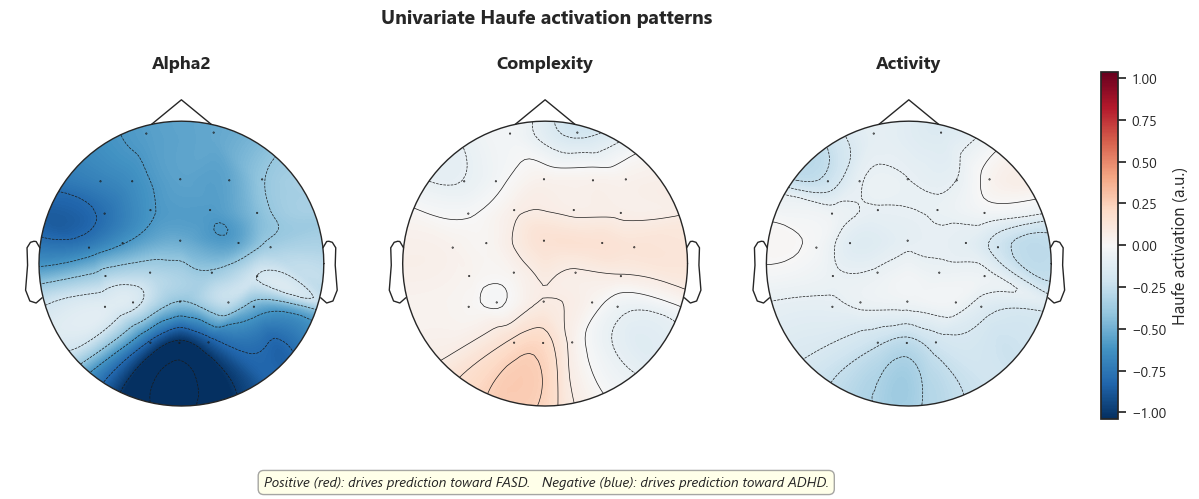

In [65]:
fig_haufe_uni = plot_univariate_haufe_panel(
    haufe_excel_path=PATH_UNIVARIATE / "B1_NESTED_HAUFE.xlsx",
    stability_excel_path=PATH_UNIVARIATE / "C1_NESTED_STABILITY.xlsx",
    features=["Alpha2", "Complexity", "Activity"],
    min_stability=0,   # set e.g. 50 to mask out electrodes selected in <50% of folds
    save_path=PATH_UNIVARIATE / "Fig_3_1A_Haufe_Univariate_Panel.png",
)

Figure saved to: C:\Users\Usuario\TFM\eeg_features\Univariate\Fig_3_1B_Alpha2_Voting_Margins.png


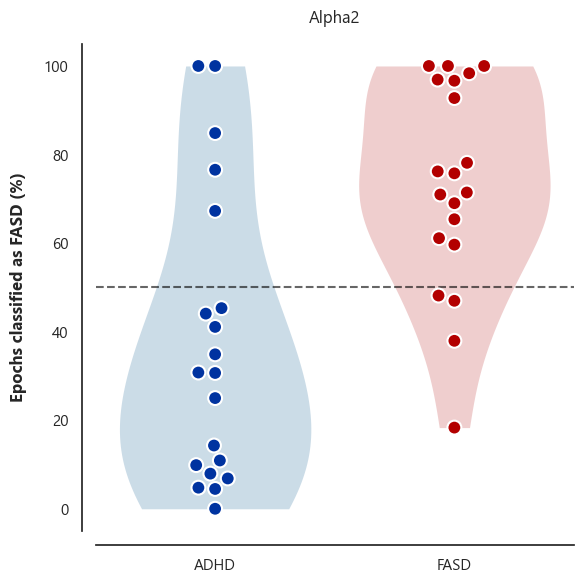

In [66]:
# Subject-level voting margin distribution
fig_voting_alpha2 = plot_voting_margins(
    voting_excel_path=PATH_UNIVARIATE / "D1_NESTED_VOTING.xlsx",
    feature="Alpha2",
    save_path=PATH_UNIVARIATE / "Fig_3_1B_Alpha2_Voting_Margins.png",
)

In [67]:
# Full clinical-utility metrics for qualifying features
show_table(
    df_sub_uni[df_sub_uni['Features'].isin(qualifying_uni)]
        [['Features', 'Precision (SD)', 'Balanced Acc (SD)', 'Net Benefit (SD)']],
    "Univariate models — full clinical utility metrics (subject level)",
)

Features,Precision (SD),Balanced Acc (SD),Net Benefit (SD)
Alpha2,0.762 (0.097),0.775 (0.068),0.275 (0.110)
Complexity,0.667 (0.103),0.675 (0.072),0.125 (0.116)
Activity,0.545 (0.106),0.550 (0.081),0.100 (0.110)


### 3.4 Bivariate EEG classification

Trains one nested-LOSO L1-SVM per pairwise EEG combination
(C(14,2) = 91 models). Two thresholds govern this section, per Methods
Section 2.5:

- All 91 pairs are screened at AUC_epoch > 0.60 (the permissive univariate
  threshold extended to pairs).
- Only pairs reaching AUC_epoch > 0.70 qualify for multimodal
  integration (Section 3.5).

Figure 3.2 shows the full 91-pair epoch-level AUC matrix (Panel A) and the
Haufe activation patterns for the three qualifying pairs (Panel B).

In [68]:
# Run the bivariate engine
df_sub_biv, df_seg_biv = run_bivariate_nested(
    df_master_eeg=df_master_eeg,
    df_demo=df_demo_balanced,
    features_to_evaluate=UNIVARIATE_FEATURES,
    output_dir=PATH_BIVARIATE,
    screening_auc=0.70,
)

Evaluation_Level,Accuracy (SD),AUC-ROC (SD),Precision (SD),Sensitivity (SD),Specificity (SD),Balanced Acc (SD),Net Benefit (SD),Model
Subject-Level (Majority Voting),0.775 (0.066),0.820 (0.071),0.789 (0.094),0.750 (0.102),0.800 (0.087),0.775 (0.067),0.275 (0.101),Complexity + Alpha2
Subject-Level (Majority Voting),0.825 (0.061),0.783 (0.078),0.810 (0.089),0.850 (0.083),0.800 (0.091),0.825 (0.062),0.225 (0.103),Alpha2 + Beta1
Subject-Level (Majority Voting),0.775 (0.068),0.745 (0.082),0.739 (0.095),0.850 (0.083),0.700 (0.106),0.775 (0.067),0.200 (0.109),Alpha2 + Beta


Bivariate nested LOSO complete. 3/91 pairs exceeded the screening threshold. Full results for all 91 pairs saved to C:\Users\Usuario\TFM\eeg_features\Bivariate.


In [69]:
# Display the bivariate summary
qualifying_biv = df_seg_biv.loc[df_seg_biv['_raw_auc'] >= 0.70, 'Model'].tolist()

table_biv = build_performance_table(
    df_seg=df_seg_biv[df_seg_biv['Model'].isin(qualifying_biv)],
    df_sub=df_sub_biv[df_sub_biv['Model'].isin(qualifying_biv)],
    name_col='Model',
)
show_table(
    table_biv.drop(columns=['_raw_auc_epoch']),
    "Bivariate EEG Classification (AUC_epoch \u2265 0.70, qualifying for multimodal integration)",
)

Model,Epoch AUC (SD),Epoch Acc (SD),Subj AUC (SD),Subj Acc (SD),Sens (SD),Spec (SD)
Complexity + Alpha2,0.727 (0.010),0.675 (0.009),0.820 (0.071),0.775 (0.066),0.750 (0.102),0.800 (0.087)
Alpha2 + Beta1,0.719 (0.010),0.680 (0.010),0.783 (0.078),0.825 (0.061),0.850 (0.083),0.800 (0.091)
Alpha2 + Beta,0.702 (0.011),0.686 (0.010),0.745 (0.082),0.775 (0.068),0.850 (0.083),0.700 (0.106)


In [70]:
# Full clinical-utility metrics for qualifying pairs 
show_table(
    df_sub_biv[df_sub_biv['Model'].isin(qualifying_biv)]
        [['Model', 'Precision (SD)', 'Balanced Acc (SD)', 'Net Benefit (SD)']],
    "Bivariate models — full clinical utility metrics (subject level)",
)

Model,Precision (SD),Balanced Acc (SD),Net Benefit (SD)
Complexity + Alpha2,0.789 (0.094),0.775 (0.067),0.275 (0.101)
Alpha2 + Beta1,0.810 (0.089),0.825 (0.062),0.225 (0.103)
Alpha2 + Beta,0.739 (0.095),0.775 (0.067),0.200 (0.109)


Figure saved to: C:\Users\Usuario\TFM\eeg_features\Bivariate\Fig_3_2_Bivariate_Combined.png


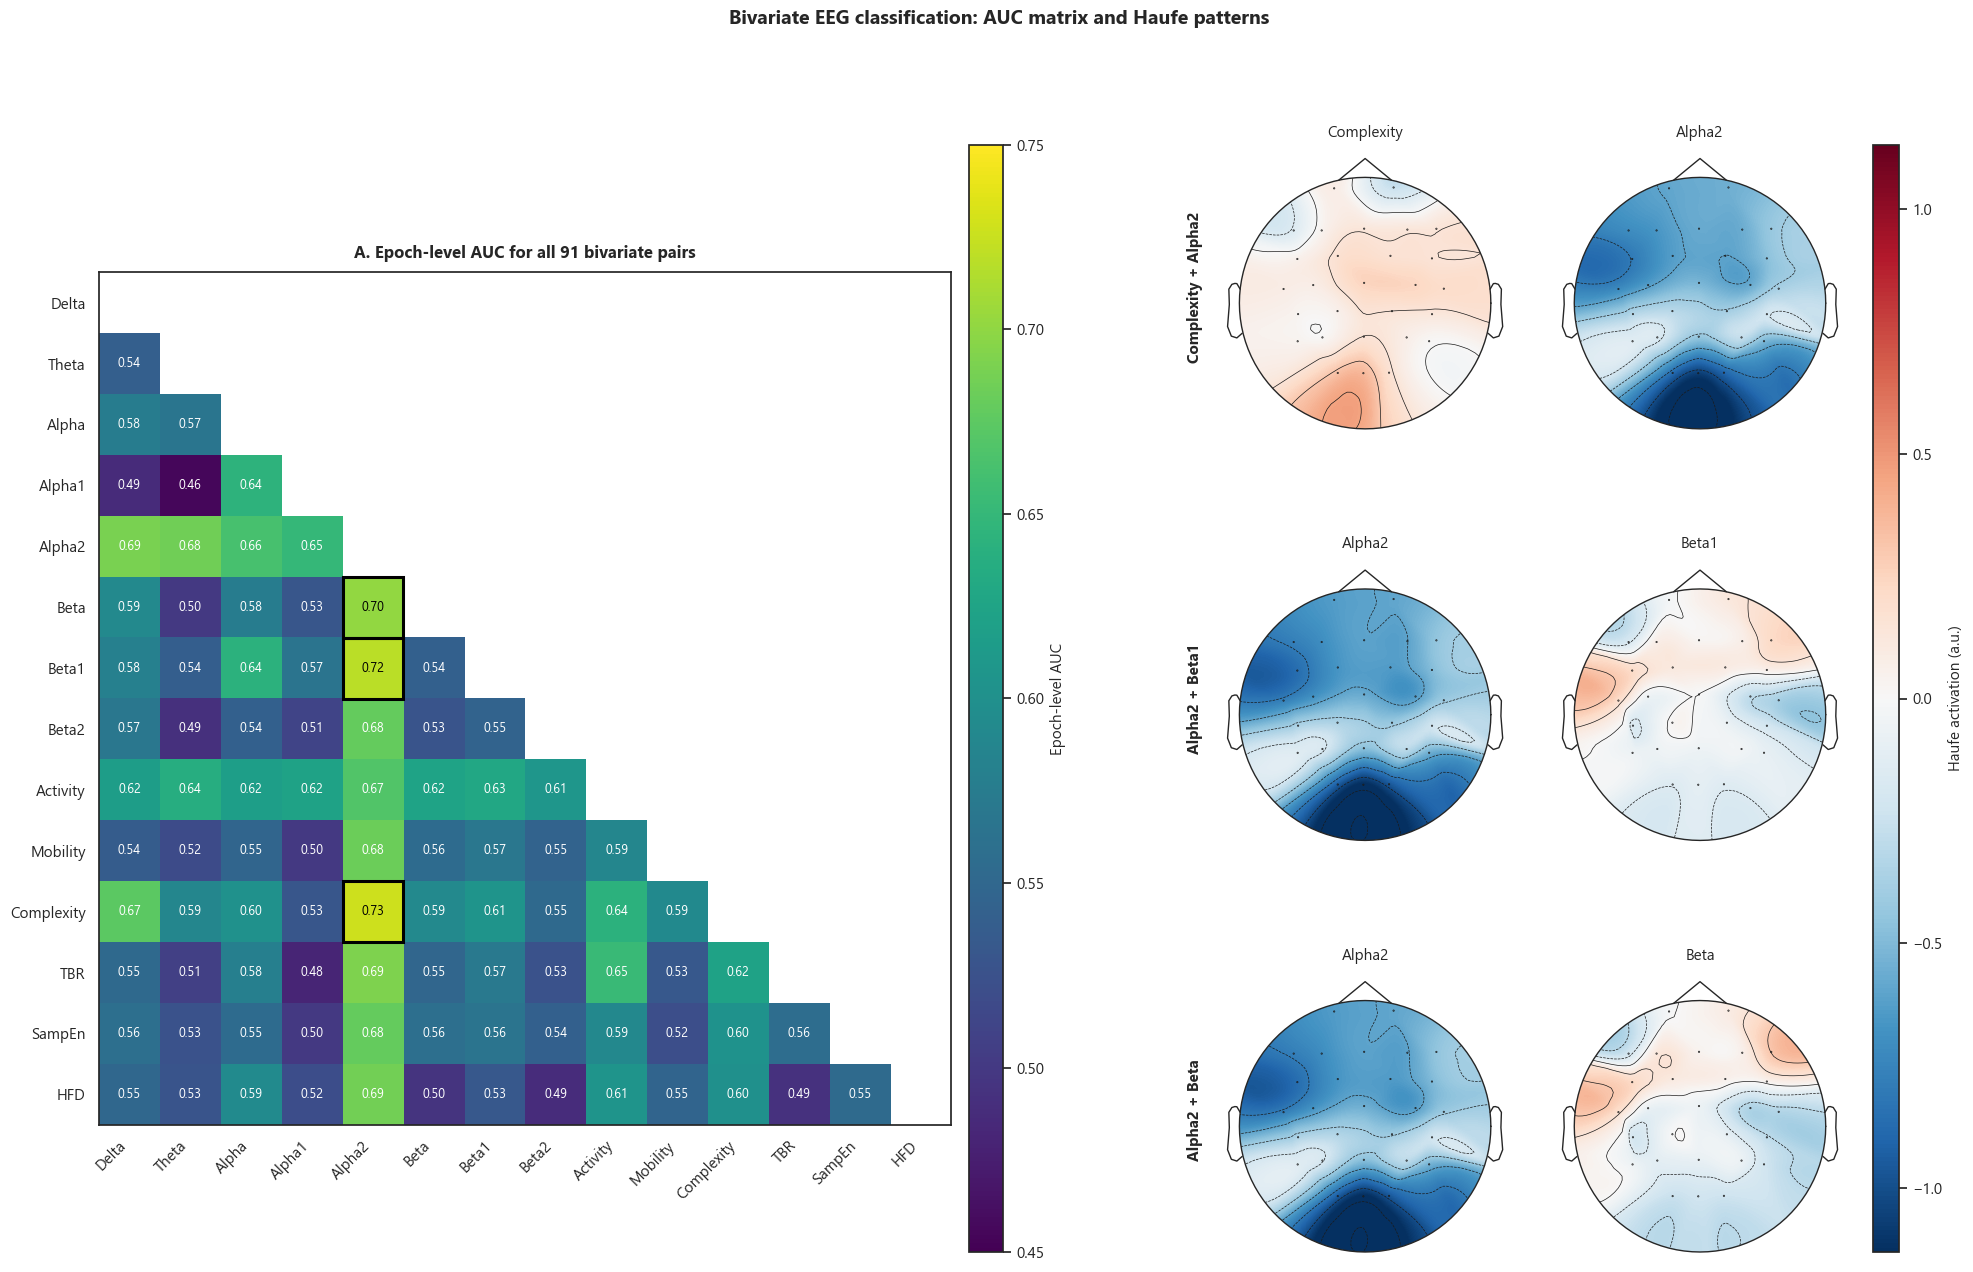

In [74]:
# Bivariate AUC matrix + Haufe patterns for qualifying pairs 
FEATURE_DISPLAY_ORDER = [
    'Delta', 'Theta', 'Alpha', 'Alpha1', 'Alpha2',
    'Beta', 'Beta1', 'Beta2', 'Activity', 'Mobility',
    'Complexity', 'TBR', 'SampEn', 'HFD',
]

fig_biv = plot_bivariate_combined_panel(
    df_seg_biv=df_seg_biv,
    spatial_dir=PATH_BIVARIATE,
    qualifying_models=qualifying_biv,   
    min_stability=0,                   
    save_path=PATH_BIVARIATE / "Fig_3_2_Bivariate_Combined.png",
)

### 3.5 Neuropsychological feature selection

1. Screen the 18 candidate NP scores for redundancy (Spearman |r| > 0.80)
   and normality (Shapiro-Wilk).
2. Run a nested-LOSO L1-SVM on all 18 features ("global NP model") to
   identify which ones survive L1 regularization in 100% of outer folds.
3. Re-run the pipeline using only those stable features ("selected NP
   model"), which produces the NP baseline reported in Table 3.1
   ("TIQ + S-WC" row) and is reused as the cognitive component of the
   multimodal fusion in Section 3.5.

In [75]:
# Paths and candidate feature definition 
PATH_NP_FEATURES = BASE_DIR / "np_features"
PATH_NP_FEATURES.mkdir(parents=True, exist_ok=True)

NP_STABILITY_THRESHOLD = 100  # % of folds

df_np_subjects = pd.read_excel(PATH_NP_SCORES_CLEAN)
df_demo_subjects = pd.read_excel(PATH_DEMOGRAPHICS_CLEAN)

if 'Group' not in df_np_subjects.columns:
    df_np_subjects['Group'] = df_np_subjects['Subject'].apply(
        lambda x: 'FASD' if 'fasd' in str(x).lower() else 'ADHD'
    )

CLINICAL_METADATA_COLS = ['Group', 'Subject', 'Sex', 'Age']

NP_CANDIDATE_FEATURES = [
    'TIQ',
    'StroopW_PCTL', 'StroopC_PCTL', 'StroopWC_PCTL',
    'FacesC_PCTL', 'FacesE_PCTL', 'FacesCE_PCTL', 'FacesICI_PCTL',
    'FDT-R_PCTL', 'FDT-Co_PCTL', 'FDT-S_PCTL', 'FDT-Ch_PCTL', 'FDT-II_PCTL', 'FDT-FI_PCTL',
    'FDT-R-Err', 'FDT-Co-Err', 'FDT-Ch-Err', 'FDT-S-Err',
]
NP_CANDIDATE_FEATURES = [f for f in NP_CANDIDATE_FEATURES if f in df_np_subjects.columns]

selected_cols = CLINICAL_METADATA_COLS + NP_CANDIDATE_FEATURES
df_np_performance = df_np_subjects[[c for c in selected_cols if c in df_np_subjects.columns]].copy()

show_table(
    pd.DataFrame([{
        'Stage': 'Candidate set (objective performance scores)',
        'N features': len(NP_CANDIDATE_FEATURES),
        'Features': ", ".join(NP_CANDIDATE_FEATURES),
    }]),
    "NP Candidate Feature Set",
)

Stage,N features,Features
Candidate set (objective performance scores),18,"TIQ, StroopW_PCTL, StroopC_PCTL, StroopWC_PCTL, FacesC_PCTL, FacesE_PCTL, FacesCE_PCTL, FacesICI_PCTL, FDT-R_PCTL, FDT-Co_PCTL, FDT-S_PCTL, FDT-Ch_PCTL, FDT-II_PCTL, FDT-FI_PCTL, FDT-R-Err, FDT-Co-Err, FDT-Ch-Err, FDT-S-Err"


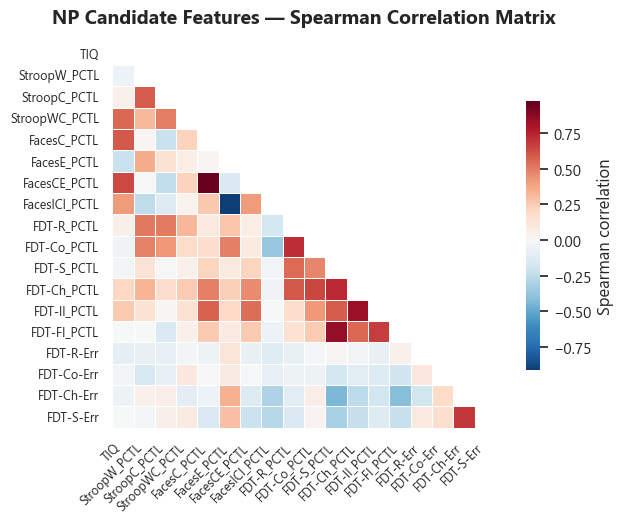

Feature A,Feature B,|r| (Spearman)
FacesC_PCTL,FacesCE_PCTL,0.974
FacesE_PCTL,FacesICI_PCTL,0.914
FDT-S_PCTL,FDT-FI_PCTL,0.852
FDT-Ch_PCTL,FDT-II_PCTL,0.840


In [76]:
# Correlation redundancy audit
_ = audit_feature_correlations(
    df_np_performance, threshold=0.80, method='spearman',
    title="NP Candidate Features — Spearman Correlation Matrix",
)

In [77]:
# Combined normality + group-difference test
_ = analyze_group_differences_auto(df_np_performance, NP_CANDIDATE_FEATURES)

Feature,Test,FASD (M),ADHD (M),p-value,Effect size,FASD (Mdn),ADHD (Mdn)
TIQ,Student's t,82.40,96.80,0.0003,d = -1.25,NaN,NaN
StroopW_PCTL,Mann-Whitney U,NaN,NaN,0.3971,r = 0.421,38.00,44.00
StroopC_PCTL,Mann-Whitney U,NaN,NaN,0.0021,r = 0.215,39.00,45.50
StroopWC_PCTL,Student's t,38.81,47.20,<0.0001,d = -1.61,NaN,NaN
FacesC_PCTL,Mann-Whitney U,NaN,NaN,0.6545,r = 0.458,42.50,55.00
FacesE_PCTL,Mann-Whitney U,NaN,NaN,0.9020,r = 0.512,90.00,80.00
FacesCE_PCTL,Mann-Whitney U,NaN,NaN,0.6151,r = 0.453,37.50,50.00
FacesICI_PCTL,Student's t,25.01,28.85,0.4883,d = -0.22,NaN,NaN
FDT-R_PCTL,Mann-Whitney U,NaN,NaN,0.0938,r = 0.345,3.50,15.00
FDT-Co_PCTL,Mann-Whitney U,NaN,NaN,0.2714,r = 0.399,2.00,10.00


In [78]:
# Global NP model (all 18 features)
report_np_global, df_np_stability_raw, _, _, selected_cs_global = execute_nested_loso_pipeline(
    df_data=df_np_performance,
    feature_cols=NP_CANDIDATE_FEATURES,
    df_demo=df_demo_subjects,
    c_grid=C_GRID,
    model_title="Global NP Model (18 features)",
)

df_np_stability_raw['Stability_Percentage'] = df_np_stability_raw['Stability_Percentage'].round(2)
df_np_stability_raw.to_excel(PATH_NP_FEATURES / 'A1_NP_STABILITY_REPORT.xlsx', index=False)

c_mode_global = max(set(selected_cs_global), key=selected_cs_global.count)
pd.DataFrame([{
    'Model': 'Global NP Model (18 features)',
    'C_values_selected': str(selected_cs_global),
    'C_mode': c_mode_global,
}]).to_excel(PATH_NP_FEATURES / 'B1_NP_C_SELECTION_LOG.xlsx', index=False)

show_table(
    df_np_stability_raw[['Feature_Name', 'Stability_Percentage']].head(10)
        .assign(**{'Stability_Percentage': lambda d: d['Stability_Percentage'].map('{:.2f}'.format)}),
    "Top 10 Neuropsychological Features by L1 Stability",
)

Feature_Name,Stability_Percentage
TIQ,100.00
StroopWC_PCTL,100.00
StroopC_PCTL,15.00
StroopW_PCTL,12.50
FDT-R-Err,2.50
FacesC_PCTL,0.00
FacesCE_PCTL,0.00
FacesICI_PCTL,0.00
FDT-R_PCTL,0.00
FacesE_PCTL,0.00


In [79]:
# Derive stable features and run the selected NP model
stable_np_features = (
    df_np_stability_raw.loc[df_np_stability_raw['Stability_Percentage'] >= NP_STABILITY_THRESHOLD, 'Feature_Name']
    .tolist()
)
print(f"NP features with {NP_STABILITY_THRESHOLD}% fold stability: {stable_np_features}")

report_np_selected, df_np_stability_selected, _, df_pat_np, selected_cs_np = execute_nested_loso_pipeline(
    df_data=df_np_performance,
    feature_cols=stable_np_features,
    df_demo=df_demo_subjects,
    c_grid=C_GRID,
    model_title="Selected NP Model",
)

# Save subject-level predictions for the Figure 3.3 ROC comparison
df_pat_np.to_excel(PATH_NP_FEATURES / "ROC_SUBJECT_NP_baseline.xlsx", index=False)

report_np_selected.to_excel(PATH_NP_FEATURES / 'C1_NP_PERFORMANCE.xlsx', index=False)

show_table(
    report_np_selected.drop(columns=['_raw_auc']).assign(Model_Name='Selected NP Model (' + " + ".join(stable_np_features) + ')'),
    "Clinical Utility — Selected NP Model (Table 3.1 baseline)",
)

NP features with 100% fold stability: ['TIQ', 'StroopWC_PCTL']


Evaluation_Level,Accuracy (SD),AUC-ROC (SD),Precision (SD),Sensitivity (SD),Specificity (SD),Balanced Acc (SD),Net Benefit (SD),Model_Name
Subject-Level (Majority Voting),0.800 (0.062),0.857 (0.063),0.773 (0.089),0.850 (0.083),0.750 (0.096),0.800 (0.063),0.300 (0.107),Selected NP Model (TIQ + StroopWC_PCTL)
Segment-Level (Epochs),0.800 (0.064),0.857 (0.061),—,—,—,—,—,Selected NP Model (TIQ + StroopWC_PCTL)


### 3.6 Multimodal classification

Integrates the EEG configurations that qualified at the univariate
(AUC_epoch > 0.60) or bivariate (AUC_epoch > 0.70) screening stage
with the stable NP feature set from Section 3.4. This yields exactly
6 multimodal models, matching Table 3.1.

In [80]:
# Run the 6 multimodal models
df_np_balanced = pd.read_excel(PATH_NP_SCORES_BALANCED)

EEG_SCENARIOS_MULTIMODAL = [
    ['Complexity'], ['Alpha2'], ['Activity'],
    ['Alpha2', 'Complexity'], ['Alpha2', 'Beta1'], ['Alpha2', 'Beta'],
]

df_sub_mm, df_seg_mm = run_multimodal_nested(
    df_eeg_master=df_master_eeg,
    df_np_master=df_np_balanced,
    df_demo=df_demo_balanced,
    eeg_scenarios_to_evaluate=EEG_SCENARIOS_MULTIMODAL,
    np_features_fixed=stable_np_features,   
    output_dir=PATH_MULTIMODAL,
)

Multimodal nested LOSO complete: 6 models trained.


In [81]:
# Table for multimodal block + full clinical utility 
table_mm = build_performance_table(df_seg=df_seg_mm, df_sub=df_sub_mm, name_col='Model')
show_table(table_mm.drop(columns=['_raw_auc_epoch']), "Multimodal Classification (Table 3.1, multimodal block)")

show_table(
    df_sub_mm[['Model', 'Precision (SD)', 'Balanced Acc (SD)', 'Net Benefit (SD)']],
    "Multimodal models — full clinical utility metrics (subject level)",
)

Model,Epoch AUC (SD),Epoch Acc (SD),Subj AUC (SD),Subj Acc (SD),Sens (SD),Spec (SD)
EEG(Complexity) + NP(TIQ + StroopWC_PCTL),0.850 (0.007),0.781 (0.008),0.860 (0.064),0.800 (0.062),0.850 (0.083),0.750 (0.096)
EEG(Alpha2 + Complexity) + NP(TIQ + StroopWC_PCTL),0.846 (0.008),0.788 (0.008),0.860 (0.061),0.825 (0.059),0.900 (0.071),0.750 (0.094)
EEG(Alpha2) + NP(TIQ + StroopWC_PCTL),0.834 (0.008),0.776 (0.008),0.830 (0.066),0.775 (0.066),0.850 (0.085),0.700 (0.101)
EEG(Activity) + NP(TIQ + StroopWC_PCTL),0.823 (0.008),0.761 (0.009),0.825 (0.070),0.775 (0.065),0.850 (0.083),0.700 (0.101)
EEG(Alpha2 + Beta) + NP(TIQ + StroopWC_PCTL),0.792 (0.009),0.749 (0.008),0.785 (0.075),0.775 (0.067),0.800 (0.093),0.750 (0.095)
EEG(Alpha2 + Beta1) + NP(TIQ + StroopWC_PCTL),0.783 (0.009),0.743 (0.009),0.795 (0.073),0.750 (0.069),0.800 (0.093),0.700 (0.101)


Model,Precision (SD),Balanced Acc (SD),Net Benefit (SD)
EEG(Complexity) + NP(TIQ + StroopWC_PCTL),0.773 (0.089),0.800 (0.063),0.300 (0.107)
EEG(Alpha2 + Complexity) + NP(TIQ + StroopWC_PCTL),0.783 (0.086),0.825 (0.058),0.325 (0.108)
EEG(Alpha2) + NP(TIQ + StroopWC_PCTL),0.739 (0.091),0.775 (0.066),0.275 (0.111)
EEG(Activity) + NP(TIQ + StroopWC_PCTL),0.739 (0.091),0.775 (0.064),0.275 (0.111)
EEG(Alpha2 + Beta1) + NP(TIQ + StroopWC_PCTL),0.727 (0.095),0.750 (0.070),0.250 (0.110)
EEG(Alpha2 + Beta) + NP(TIQ + StroopWC_PCTL),0.762 (0.095),0.775 (0.068),0.275 (0.107)


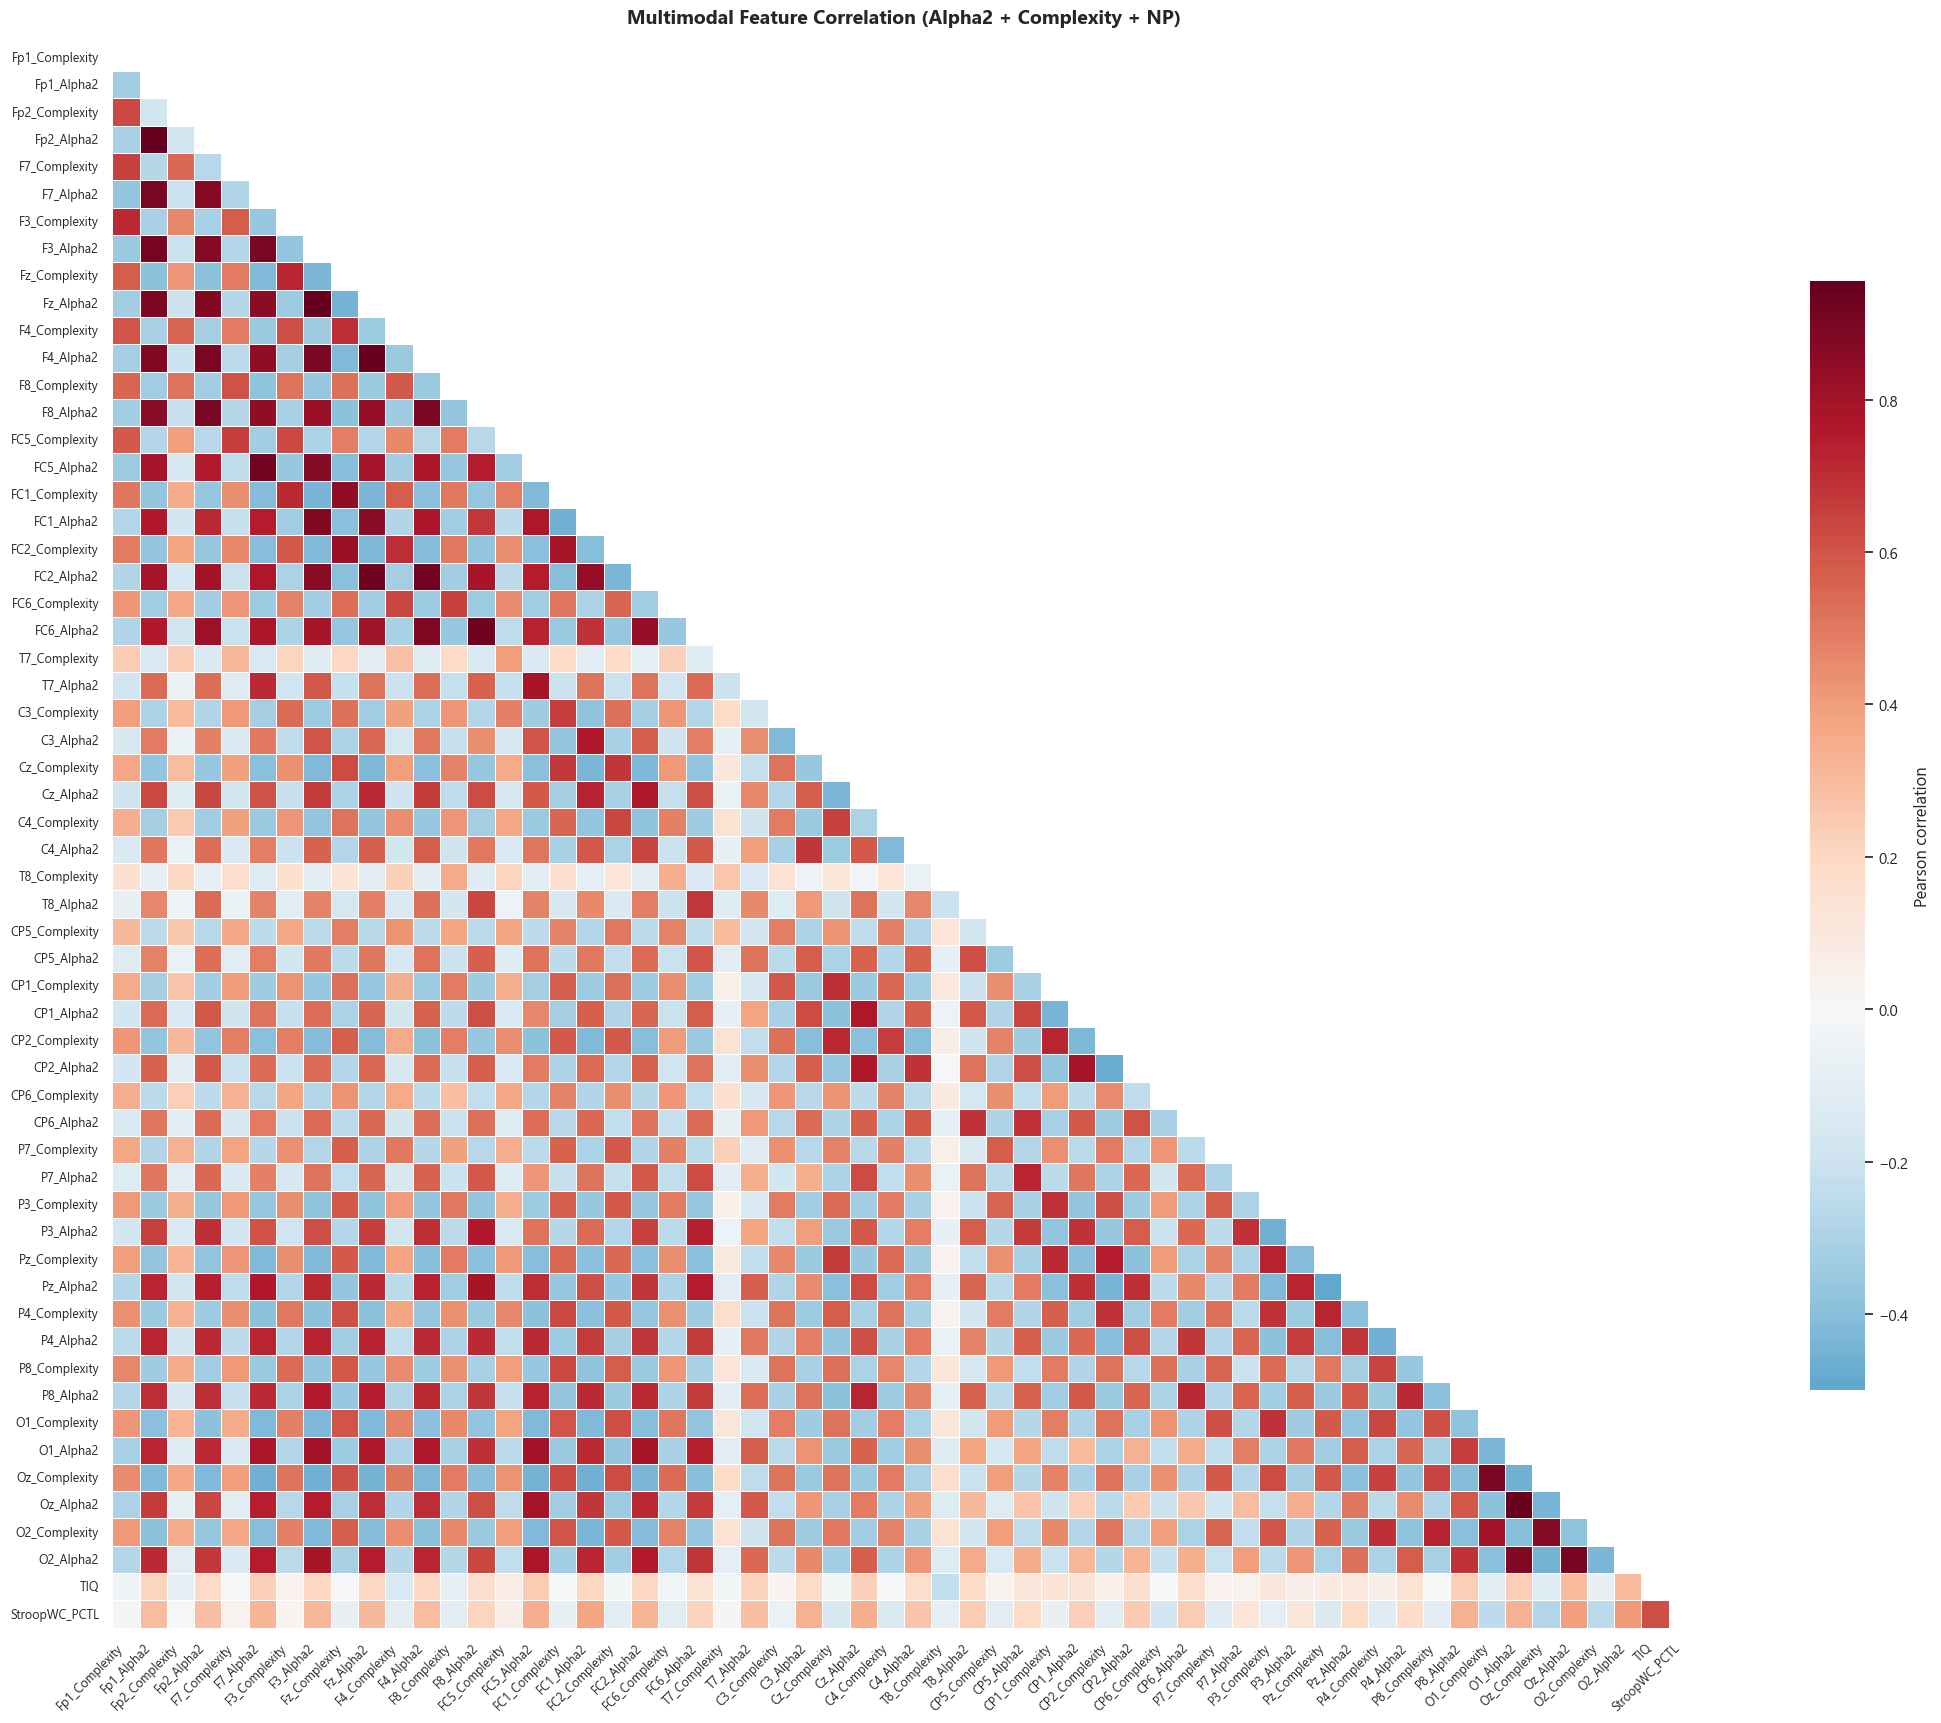

Feature A,Feature B,|r| (Pearson)
Fp1_Alpha2,Fp2_Alpha2,0.955
F3_Alpha2,Fz_Alpha2,0.951
Fz_Alpha2,F4_Alpha2,0.949
O1_Alpha2,Oz_Alpha2,0.942
F8_Alpha2,FC6_Alpha2,0.924
Fz_Alpha2,FC2_Alpha2,0.921
F4_Alpha2,FC2_Alpha2,0.917
F7_Alpha2,FC5_Alpha2,0.916
Oz_Alpha2,O2_Alpha2,0.912
Fp1_Alpha2,F3_Alpha2,0.910


In [82]:
# Multimodal feature correlation audit 
df_multimodal_check = pd.merge(
    df_master_eeg, df_np_balanced[['Subject'] + stable_np_features], on='Subject', how='inner'
)
mm_check_cols = (
    [c for c in df_multimodal_check.columns if any(c.endswith(f'_{f}') for f in ['Alpha2', 'Complexity'])]
    + stable_np_features
)
_ = audit_feature_correlations(
    df_multimodal_check[mm_check_cols], threshold=0.80, method='pearson',
    exclude_cols=[], title="Multimodal Feature Correlation (Alpha2 + Complexity + NP)",
)

C:\Users\Usuario\AppData\Local\Temp\ipykernel_6064\1300110325.py:816: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Figure saved to: C:\Users\Usuario\TFM\eeg_features\Multimodal\Fig_3_3_ROC_Confusion.png


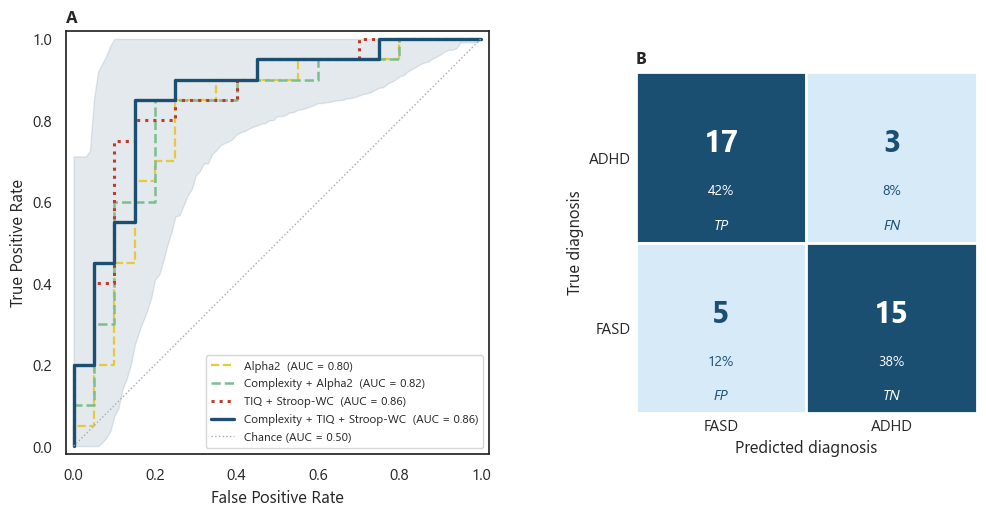

In [87]:
# ROC curves + confusion matrix
roc_models = [
    {'label': 'Alpha2', 'path': PATH_UNIVARIATE / 'ROC_SUBJECT' / 'ROC_SUBJECT_Alpha2.xlsx',
     'color': '#E8C93A', 'ls': '--', 'lw': 1.6},
    {'label': 'Complexity + Alpha2', 'path': PATH_BIVARIATE / 'ROC_SUBJECT' / 'ROC_SUBJECT_Complexity_Alpha2.xlsx',
     'color': '#7DBE8E', 'ls': '--', 'lw': 1.8},
    {'label': 'TIQ + Stroop-WC', 'path': PATH_NP_FEATURES / 'ROC_SUBJECT_NP_baseline.xlsx',
     'color': '#C0392B', 'ls': ':', 'lw': 2.2},
    {'label': 'Complexity + TIQ + Stroop-WC', 'path': PATH_MULTIMODAL / 'ROC_SUBJECT' / 'ROC_SUBJECT_Complexity_with_NP.xlsx',
     'color': '#1B4F72', 'ls': '-', 'lw': 2.4, 'ci': True},
]

fig_roc_cm = plot_fig_roc_confusion(
    roc_models=roc_models,
    best_model_path=PATH_MULTIMODAL / 'ROC_SUBJECT' / 'ROC_SUBJECT_Complexity_with_NP.xlsx',
    save_path=PATH_MULTIMODAL / "Fig_3_3_ROC_Confusion.png",
)

Saved: C:\Users\Usuario\TFM\eeg_features\Multimodal\Fig_3_4_Haufe_Multimodal_Panel.png


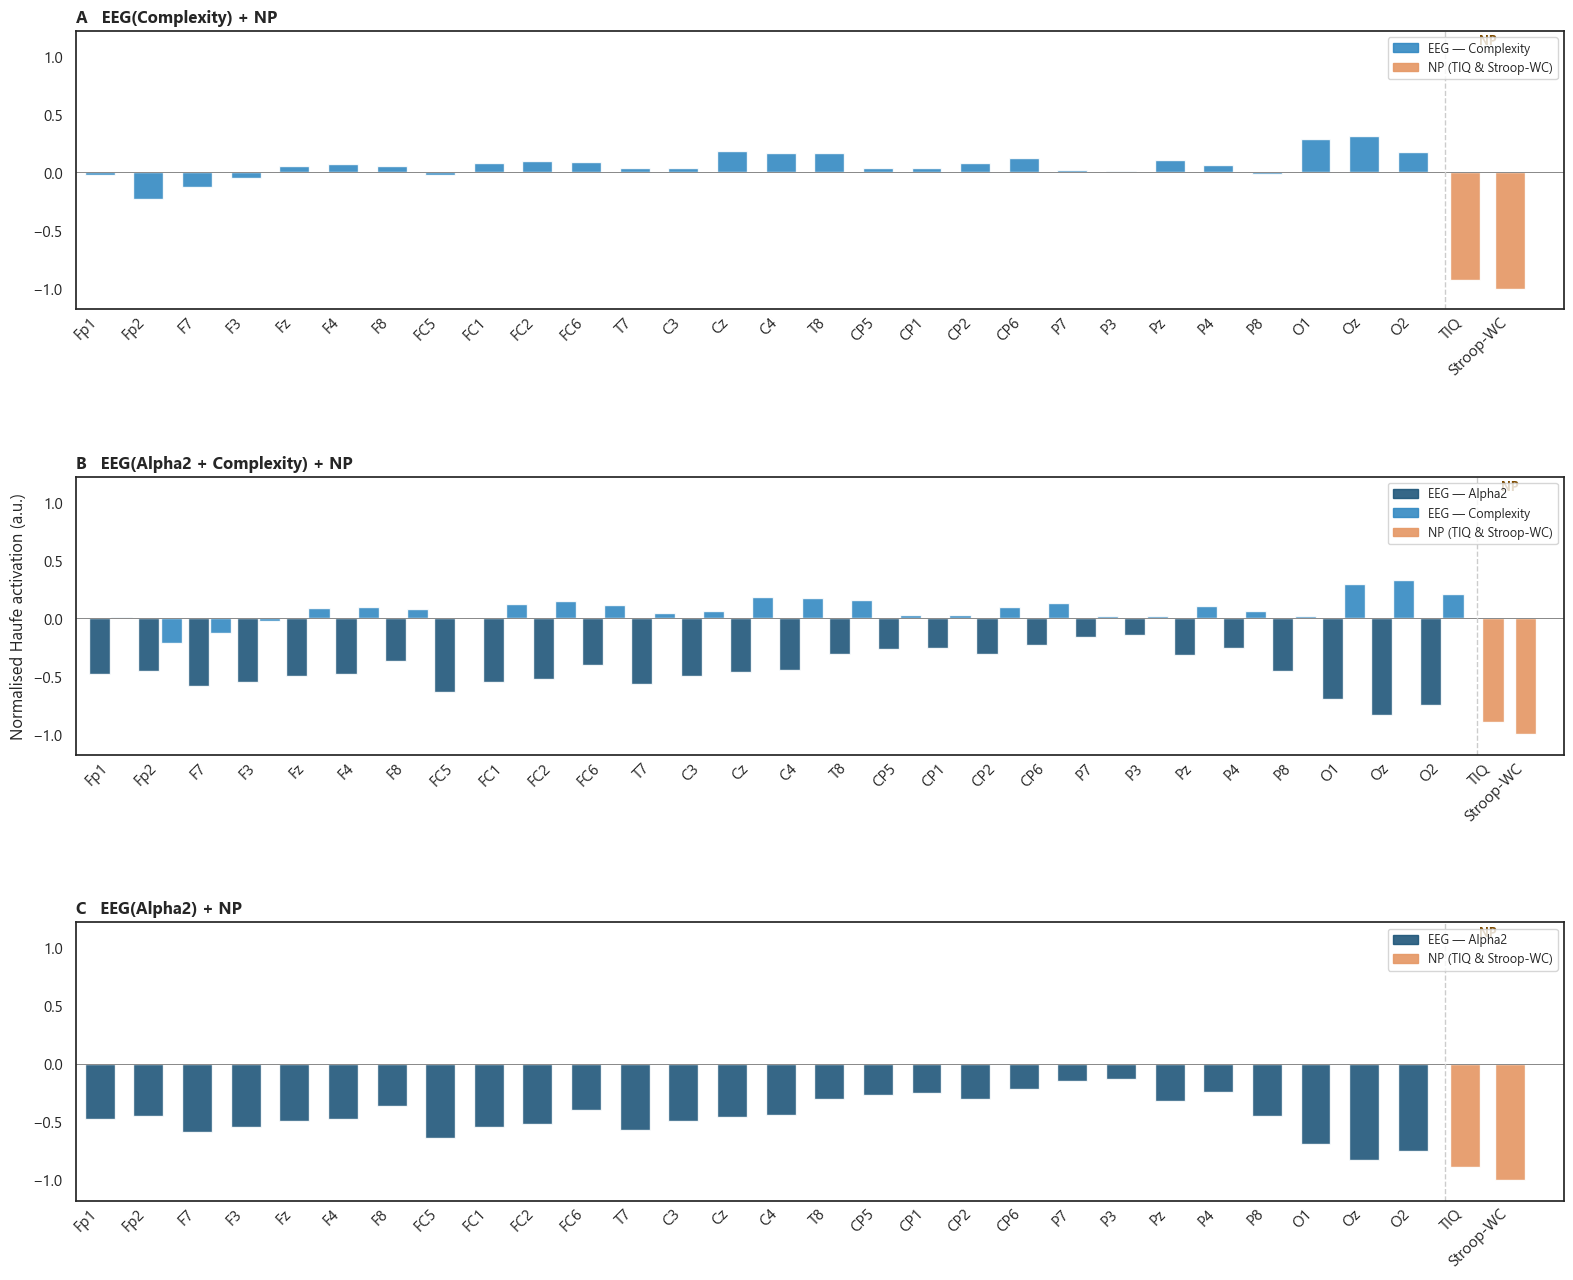

In [92]:
# Haufe multimodal bar panel 
CHANNEL_ORDER = [
    'Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'T7', 'C3', 'Cz', 'C4', 'T8', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'O1', 'Oz', 'O2',
]
NP_DISPLAY_LABELS = {'TIQ': 'TIQ', 'StroopWC_PCTL': 'Stroop-WC'}

fig4_panels = [
    {'path': PATH_MULTIMODAL / 'C_MULTIMODAL_NESTED_STABILITY_Complexity_with_NP.xlsx',
     'eeg_feats': ['Complexity'], 'eeg_colors': ['#2E86C1'], 'title': 'EEG(Complexity) + NP', 'label': 'A'},
    {'path': PATH_MULTIMODAL / 'C_MULTIMODAL_NESTED_STABILITY_Alpha2_Complexity_with_NP.xlsx',
     'eeg_feats': ['Alpha2', 'Complexity'], 'eeg_colors': ['#1A5276', '#2E86C1'], 'title': 'EEG(Alpha2 + Complexity) + NP', 'label': 'B'},
    {'path': PATH_MULTIMODAL / 'C_MULTIMODAL_NESTED_STABILITY_Alpha2_with_NP.xlsx',
     'eeg_feats': ['Alpha2'], 'eeg_colors': ['#1A5276'], 'title': 'EEG(Alpha2) + NP', 'label': 'C'},
]

fig, axes = plt.subplots(3, 1, figsize=(16, 13))
plt.subplots_adjust(hspace=0.60, left=0.05, right=0.98, top=0.97, bottom=0.07)

for ax, panel in zip(axes, fig4_panels):
    if not panel['path'].exists():
        ax.set_title(f"MISSING: {panel['title']}", fontsize=9)
        continue
    haufe_eeg, haufe_np, g_max = load_multimodal_haufe(panel['path'], stable_np_features, panel['eeg_feats'])
    draw_haufe_panel(ax, haufe_eeg, haufe_np, g_max, panel['eeg_feats'], panel['eeg_colors'],
                      np_order=[NP_DISPLAY_LABELS[f] for f in stable_np_features],
                      panel_label=panel['label'], panel_title=panel['title'])
    if panel['label'] == 'B':
        ax.set_ylabel('Normalised Haufe activation (a.u.)', fontsize=12)

save_path = PATH_MULTIMODAL / 'Fig_3_4_Haufe_Multimodal_Panel.png'
fig.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"Saved: {save_path}")
plt.show()

#### Demographic bias audit for the top 3 multimodal models

For each of the three leading multimodal configurations (Figure 3.4), this
audit repeats the same demographic residualization used inside
`execute_nested_loso_pipeline` (age + sex, fit on training subjects only),
but instead of predicting FASD vs. ADHD, it tries to predict the
confounders themselves — biological sex (classification) and chronological
age (regression) — from the residualized feature space.

If residualization worked as intended, the resulting feature space should
carry little to no demographic signal: sex classification should sit near
chance (AUC \u2248 0.50) and age regression should show no significant
correlation between true and predicted age. This is a sanity check on the
deconfounding step, not a clinical model.

In [93]:
def run_demographic_bias_audit(df_eeg_master, df_np_master, df_demo, eeg_feats, np_features_fixed,
                                 model_label, c_penalty=0.05):
    """
    Audits whether biological sex or chronological age can still be
    predicted from a given multimodal feature set after the same
    age+sex residualization used for FASD/ADHD classification.

    Returns a results dict (sex AUC/accuracy, age MAE/R2/Pearson r and
    p-value, and a pass/fail flag per target) plus the subject-level
    audit DataFrame (for optional plotting).
    """
    df_np_sub = df_np_master[['Subject'] + np_features_fixed].drop_duplicates(subset=['Subject'])
    df_mm = pd.merge(df_eeg_master, df_np_sub, on='Subject', how='inner')

    eeg_cols = [c for c in df_mm.columns if any(c.endswith(f'_{f}') for f in eeg_feats)]
    feature_cols = eeg_cols + np_features_fixed
    if not eeg_cols:
        raise ValueError(f"No EEG columns found for scenario '{eeg_feats}' in model '{model_label}'.")

    sex_enc = df_demo['Sex'].astype(str).str.upper().str.startswith('M')
    subject_to_sex = dict(zip(df_demo['Subject'], sex_enc.astype(int)))
    subject_to_age = dict(zip(df_demo['Subject'], df_demo['Age']))

    df_mm['Sex_Encoded'] = df_mm['Subject'].map(subject_to_sex)
    df_mm['Age_Raw'] = df_mm['Subject'].map(subject_to_age)
    if df_mm['Sex_Encoded'].isnull().any() or df_mm['Age_Raw'].isnull().any():
        raise ValueError(f"Demographic mapping failed for model '{model_label}'.")

    X = df_mm[feature_cols].values.astype(float)
    groups = df_mm['Subject'].values
    y_sex = df_mm['Sex_Encoded'].values.astype(float)
    y_age = df_mm['Age_Raw'].values.astype(float)

    logo = LeaveOneGroupOut()
    scaler = StandardScaler()
    svm_sex = LinearSVC(penalty='l1', dual=False, C=c_penalty, max_iter=15000,
                         class_weight='balanced', random_state=42)
    svm_age = LinearSVR(C=c_penalty, max_iter=15000, random_state=42)

    y_pred_sex, y_prob_sex = np.zeros(len(y_sex)), np.zeros(len(y_sex))
    y_pred_age = np.zeros(len(y_age))

    for train_idx, test_idx in logo.split(X, groups=groups):
        cov_tr = np.column_stack((y_sex[train_idx], y_age[train_idx]))
        cov_te = np.column_stack((y_sex[test_idx], y_age[test_idx]))

        X_tr_res, X_te_res = remove_demographic_variance(X[train_idx], cov_tr, X[test_idx], cov_te)
        X_tr_sc = scaler.fit_transform(X_tr_res)
        X_te_sc = scaler.transform(X_te_res)

        svm_sex.fit(X_tr_sc, y_sex[train_idx])
        y_pred_sex[test_idx] = svm_sex.predict(X_te_sc)
        y_prob_sex[test_idx] = expit(svm_sex.decision_function(X_te_sc))

        svm_age.fit(X_tr_sc, y_age[train_idx])
        y_pred_age[test_idx] = svm_age.predict(X_te_sc)

    df_audit = pd.DataFrame({
        'Subject': groups,
        'Real_Sex': y_sex, 'Pred_Sex': y_pred_sex, 'Prob_Sex': y_prob_sex,
        'Real_Age': y_age, 'Pred_Age': y_pred_age,
    })
    patient_audit = df_audit.groupby('Subject').agg(
        Real_Sex=('Real_Sex', 'first'), Pred_Sex=('Pred_Sex', majority_vote_fasd_tiebreak),
        Prob_Sex=('Prob_Sex', 'mean'), Real_Age=('Real_Age', 'first'), Pred_Age=('Pred_Age', 'mean'),
    ).reset_index()

    acc_sex = accuracy_score(patient_audit['Real_Sex'], patient_audit['Pred_Sex'])
    auc_sex = roc_auc_score(patient_audit['Real_Sex'], patient_audit['Prob_Sex'])
    mae_age = mean_absolute_error(patient_audit['Real_Age'], patient_audit['Pred_Age'])
    r2_age = r2_score(patient_audit['Real_Age'], patient_audit['Pred_Age'])
    r_pearson, p_val = pearsonr(patient_audit['Real_Age'], patient_audit['Pred_Age'])

    results = {
        'Model': model_label,
        'Sex AUC': auc_sex, 'Sex Acc': acc_sex,
        'Age MAE': mae_age, 'Age R2': r2_age, 'Age Pearson r': r_pearson, 'Age p-value': p_val,
        'Sex audit': 'PASS (near chance)' if auc_sex < 0.58 else 'FLAG (residual sex signal)',
        'Age audit': 'PASS (no significant link)' if p_val > 0.05 else 'FLAG (residual age signal)',
    }
    return results, patient_audit

In [94]:
# Run the audit on the 3 leading multimodal models
audit_records = []
patient_audits = {}

for panel in fig4_panels:
    results, patient_audit = run_demographic_bias_audit(
        df_eeg_master=df_master_eeg, df_np_master=df_np_balanced, df_demo=df_demo_subjects,
        eeg_feats=panel['eeg_feats'], np_features_fixed=stable_np_features,
        model_label=panel['title'],
    )
    audit_records.append(results)
    patient_audits[panel['label']] = patient_audit

df_bias_audit = pd.DataFrame(audit_records)
df_bias_audit.to_excel(PATH_MULTIMODAL / 'F1_DEMOGRAPHIC_BIAS_AUDIT.xlsx', index=False)

show_table(
    df_bias_audit[['Model', 'Sex AUC', 'Sex audit', 'Age Pearson r', 'Age p-value', 'Age audit']]
        .assign(**{
            'Sex AUC': lambda d: d['Sex AUC'].map('{:.3f}'.format),
            'Age Pearson r': lambda d: d['Age Pearson r'].map('{:.3f}'.format),
            'Age p-value': lambda d: d['Age p-value'].map('{:.3f}'.format),
        }),
    "Demographic Bias Audit — Top 3 Multimodal Models (post-residualization)",
)

Model,Sex AUC,Sex audit,Age Pearson r,Age p-value,Age audit
EEG(Complexity) + NP,0.500,PASS (near chance),-0.094,0.565,PASS (no significant link)
EEG(Alpha2 + Complexity) + NP,0.500,PASS (near chance),0.117,0.471,PASS (no significant link)
EEG(Alpha2) + NP,0.500,PASS (near chance),0.101,0.537,PASS (no significant link)


Saved: C:\Users\Usuario\TFM\eeg_features\Multimodal\Fig_Bias_Audit_Top3_Multimodal.png


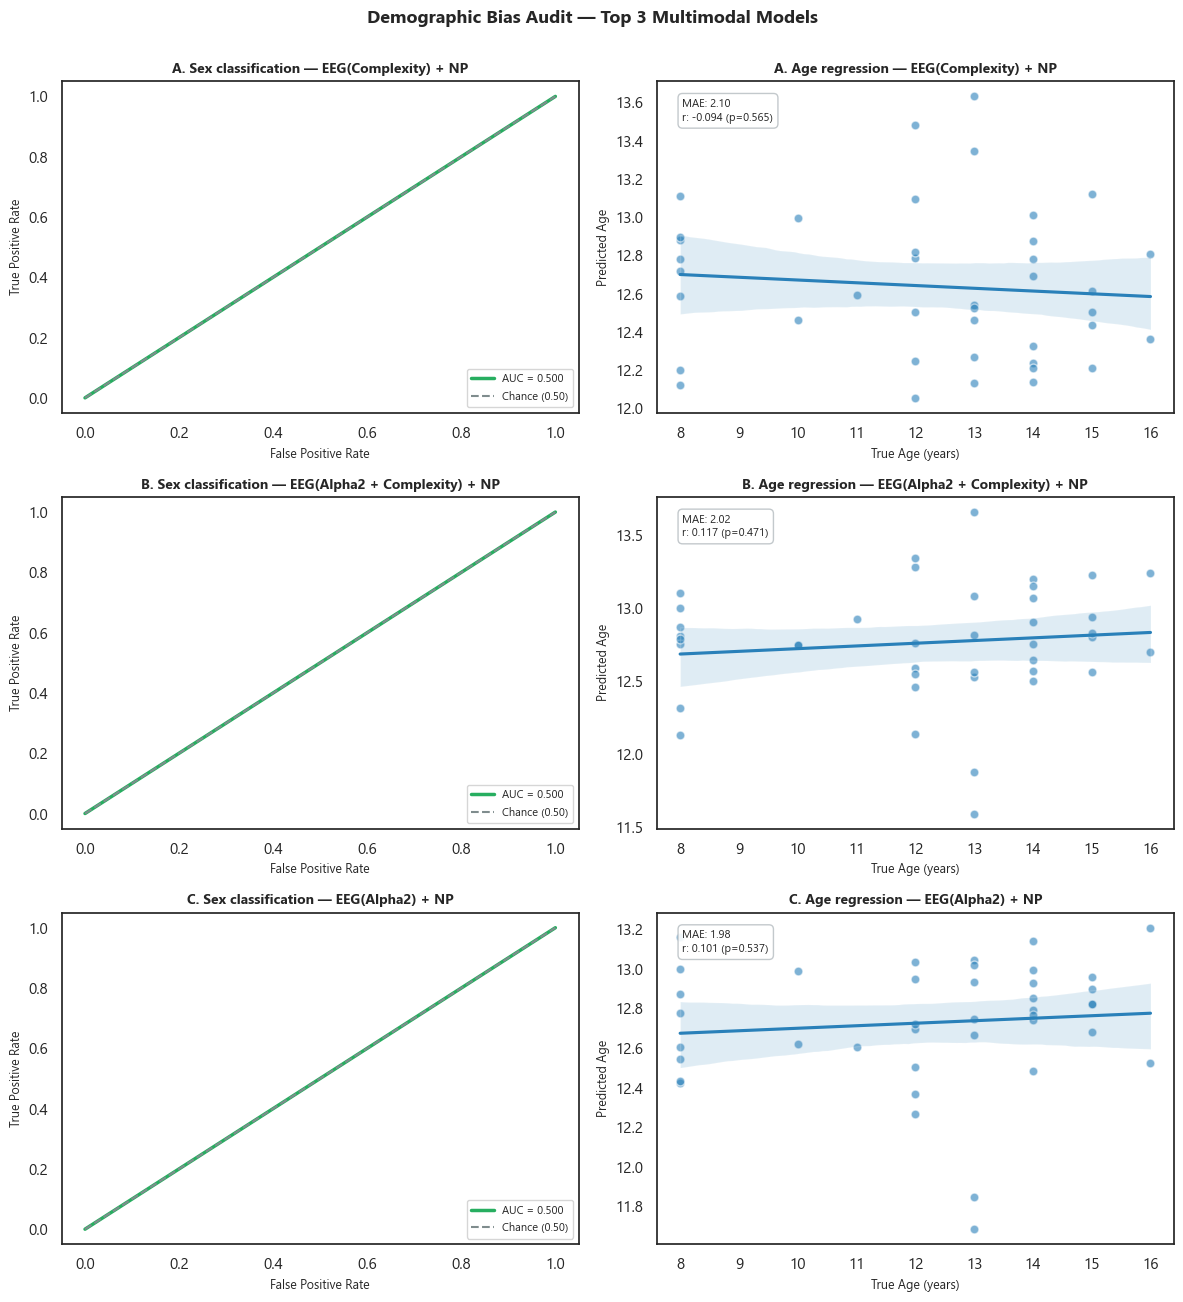

In [95]:
# Demographic bias audit panel for the 3 multimodal models ----
fig, axes = plt.subplots(3, 2, figsize=(12, 13))

for row_idx, panel in enumerate(fig4_panels):
    patient_audit = patient_audits[panel['label']]
    ax_sex, ax_age = axes[row_idx, 0], axes[row_idx, 1]

    fpr, tpr, _ = roc_curve(patient_audit['Real_Sex'], patient_audit['Prob_Sex'])
    auc_sex = sk_auc(fpr, tpr)
    ax_sex.plot(fpr, tpr, color='#27ae60', lw=2.5, label=f'AUC = {auc_sex:.3f}')
    ax_sex.plot([0, 1], [0, 1], color='#7f8c8d', lw=1.5, ls='--', label='Chance (0.50)')
    ax_sex.set_title(f"{panel['label']}. Sex classification — {panel['title']}", fontsize=10, fontweight='bold')
    ax_sex.set_xlabel('False Positive Rate', fontsize=9)
    ax_sex.set_ylabel('True Positive Rate', fontsize=9)
    ax_sex.legend(loc='lower right', fontsize=8)

    sns.regplot(x='Real_Age', y='Pred_Age', data=patient_audit, ax=ax_age, color='#2980b9',
                scatter_kws={'alpha': 0.6, 'edgecolor': 'w', 's': 40})
    mae = mean_absolute_error(patient_audit['Real_Age'], patient_audit['Pred_Age'])
    r_p, p_v = pearsonr(patient_audit['Real_Age'], patient_audit['Pred_Age'])
    ax_age.set_title(f"{panel['label']}. Age regression — {panel['title']}", fontsize=10, fontweight='bold')
    ax_age.set_xlabel('True Age (years)', fontsize=9)
    ax_age.set_ylabel('Predicted Age', fontsize=9)
    ax_age.text(0.05, 0.95, f"MAE: {mae:.2f}\nr: {r_p:.3f} (p={p_v:.3f})",
                transform=ax_age.transAxes, va='top', fontsize=8,
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#bdc3c7', alpha=0.9))

plt.suptitle("Demographic Bias Audit — Top 3 Multimodal Models", fontsize=13, fontweight='bold', y=1.0)
plt.tight_layout()
save_path = PATH_MULTIMODAL / 'Fig_Bias_Audit_Top3_Multimodal.png'
fig.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"Saved: {save_path}")
plt.show()